# **<font color="Gray"> Investment Research Agent: An Agentic AI Financial Analysis System — Team 2 </font>**

## Project overview

This notebook builds an **Investment Research Agent**: a small team of
cooperating LLM agents that researches a stock end to end. Given a ticker and
a question it plans the research, picks and runs data tools, summarises recent
news, reviews and improves its own drafts, remembers what it learned for the
next run, and produces a sourced report with charts. Everything runs on free
OpenRouter models and free Yahoo Finance data.

**GitHub repository:** `https://github.com/umea14/Investment-Research-Agent`

**How to run:** run the cells from top to bottom and paste your OpenRouter key
when prompted (it is never stored in the notebook). Free models are rate
limited, and one end-to-end run makes roughly 15-25 LLM requests, so check your
OpenRouter limits. If a cell reports "all 3 free attempts failed", wait a
minute and re-run that cell.

### Requirement map

| Requirement | Where it is implemented |
| --- | --- |
| Plans research steps for a stock | Section 4, `Coordinator.plan_research` |
| Uses tools dynamically | Sections 3-5: the LLM selects Yahoo Finance tools as JSON, and code validates the selection *before* anything runs |
| Self-reflects on output quality | Section 7, `EvaluatorAgent` |
| Learns across runs | Section 8, `LessonMemory` and `LearningCoordinator.reflect` |
| Workflow 1: prompt chaining | Section 5, `NewsResearcherAgent` |
| Workflow 2: routing | Section 6, `RoutingCoordinator.route_task` |
| Workflow 3: evaluator-optimizer | Section 7, `ReviewingCoordinator.refine_packet` |
| Evidence-based report and charts | Section 9 |
| End-to-end demonstration and tests | Section 10 |

### Agent design and workflows

The system has four agents that share one base class (`Agent`): a
**Coordinator** (plans, routes, merges, reviews and reports), a
**Researcher** (market data and numerical analysis), a **NewsResearcher**
(prompt chain over headlines) and an **Evaluator** (independent reviewer).
Agents talk through `send_to`, which logs every delegation, so each run has a
visible audit trail.

```
question + ticker
      |
  Coordinator --- plan (LLM) --- route (LLM; keyword rules if all models fail)
      |--> Researcher:     Yahoo prices + financials -> metrics (code) -> narrative (LLM)
      |--> NewsResearcher: ingest -> preprocess -> classify -> [gate] -> extract -> summarize
      |
  Evaluator <-- each draft: score -> feedback -> revise (at most 2 rounds)
      |
  LessonMemory <-- reflect on feedback; lessons are recalled next run
      |
  Coordinator --> executive summary + report + charts
```

Design principles used throughout: the LLM decides *what to do* (which tools,
which specialist, how to word things); **code** computes every number, validates
every LLM output against a schema, and bounds every loop. A failed or invalid
LLM answer is retried on at most three free models and is never replaced by an
invented one.

### Agent functions and capabilities

* **Planning:** the Coordinator writes a 3-5 step plan that respects the
  question and any excluded tools.
* **Dynamic tool use:** the Researcher chooses `get_stock_prices` and/or
  `get_company_financials` (and the period) from the question; the news agent
  uses `get_company_news`. Selections that break a constraint are rejected.
* **Analysis:** price change, drawdown, volatility and quarter-over-quarter
  growth are computed in code; the LLM only explains them, and any percentage
  it quotes must match a computed value.
* **Self-reflection:** the Evaluator scores each draft for accuracy,
  completeness and clarity against the evidence.
* **Learning:** feedback is generalised into short rules, stored in a JSON
  file, and injected into the authors' prompts on later runs.

### Evaluation and iteration

Each draft goes through a bounded evaluator-optimizer loop. The verdict is
computed in code from the scores (approve only when every score is at least
4). An automatic grounding check also caps the accuracy score
if a draft quotes a percentage that is not in the evidence. Revisions receive
the reviewer's feedback and the previous draft. First-draft versus final-draft
scores are charted in Section 9, and Section 10 compares runs to show whether
recalled lessons change the first-draft quality.

## **<font color="green">Heads Up, 429 or provider overload errors don’t necessarily mean the code is wrong, it could be due to reaching the limits of the model or model being temporarily down. The code automatically tries fallback models. If all attempts fail, wait and retry the failed cell. If the problem persists, try another available free model from OpenRouter.</font>**

---
# 1. Environment Setup and Dependencies

In [1]:
!pip install -q openai yfinance jsonschema matplotlib

In [2]:
from copy import deepcopy
from datetime import datetime, timezone
from pathlib import Path
import json
import re
import time
import uuid
from getpass import getpass

import pandas as pd
from jsonschema import Draft202012Validator, ValidationError
from openai import OpenAI, APIStatusError, APIConnectionError
import yfinance as yf

PLANNING_MODELS = (
    "nvidia/nemotron-3-super-120b-a12b:free",
    "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    "qwen/qwen3.8-27b:free",
)

RESEARCH_MODELS = (
    "nvidia/nemotron-3-super-120b-a12b:free",
    "qwen/qwen3.8-27b:free",
    "openrouter/free",
)

PERIODS = ("1mo", "3mo", "6mo", "1y", "2y", "5y")
TOOL_NAMES = ("get_stock_prices", "get_company_financials")


def utc_now():
    return datetime.now(timezone.utc).isoformat()


def normalize_ticker(ticker):
    if not isinstance(ticker, str) or not ticker.strip():
        raise ValueError("Provide a nonempty stock symbol.")
    return ticker.strip().upper()


def make_task(ticker, question, price_period=None, excluded_tools=()):
    """Optional structured constraints supplement, rather than replace, the
    question."""
    if not isinstance(question, str) or not question.strip():
        raise ValueError("Provide a nonempty research question.")
    if price_period is not None and price_period not in PERIODS:
        raise ValueError(f"price_period must be one of {PERIODS}.")
    if isinstance(excluded_tools, str) or set(excluded_tools) - set(
        TOOL_NAMES
    ):
        raise ValueError("excluded_tools must contain registered tool names.")
    return {
        "run_id": str(uuid.uuid4()),
        "ticker": normalize_ticker(ticker),
        "question": question.strip(),
        "price_period": price_period,
        "excluded_tools": list(excluded_tools),
    }


def safe_error(error):
    """Keep provider errors useful without persisting credentials or long
    payloads."""
    return re.sub(r"sk-[A-Za-z0-9_-]+", "[REDACTED]", str(error))[:300]

In [3]:
# Each teammate enters their own key. Never put the key in the notebook source.
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=getpass("Enter your OpenRouter API key: ").strip(),
    max_retries=0,
    timeout=60.0,
)
print("OpenRouter client configured.")

Enter your OpenRouter API key: ··········
OpenRouter client configured.


In [4]:
from types import SimpleNamespace


class ThrottledClient:
    """Spaces requests out so free-tier per-minute limits are not hit."""

    def __init__(self, client, min_interval=3.5, _state=None):
        self._client, self.min_interval = client, min_interval
        self._state = _state if _state is not None else {"last": 0.0}
        self.chat = SimpleNamespace(
            completions=SimpleNamespace(create=self._create)
        )

    def with_options(self, **options):
        return ThrottledClient(
            self._client.with_options(**options),
            self.min_interval,
            self._state,
        )

    def _create(self, **request):
        wait = self._state["last"] + self.min_interval - time.monotonic()
        if wait > 0:
            time.sleep(wait)
        self._state["last"] = time.monotonic()
        return self._client.chat.completions.create(**request)


client = ThrottledClient(client)
print("Requests are now spaced to respect free-tier rate limits.")

Requests are now spaced to respect free-tier rate limits.


## 2. Base Agent

Following the lab 7, each agent has a name, role, model choices, session memory, process, and send_to. LLM requests have at most three free-model attempts. Invalid outputs are rejected; unsuccessful requests remain errors.

In [5]:
class Agent:
    """Base class: identity, role, LLM calls, memory and send_to."""

    def __init__(
        self,
        name,
        role,
        client,
        models,
        event_log=None,
        verbose=True,
        retry_delay=2,
    ):
        if (
            not models
            or len(models) > 3
            or any(
                m != "openrouter/free" and not m.endswith(":free")
                for m in models
            )
        ):
            raise ValueError("Configure one to three free model IDs only.")
        self.name, self.role = name, role
        self.client, self.models = client, tuple(dict.fromkeys(models))
        self.memory = (
            []
        )  # Session history only: NOT learning across notebook restarts.
        self.event_log = event_log if event_log is not None else []
        self.verbose, self.retry_delay = verbose, retry_delay
        self.last_attempts = []

    def _log(self, message):
        if self.verbose:
            print(message)

    def call_llm(self, prompt, validator, response_format=None):
        """Bounded fallback, including invalid outputs; never fabricate a
        response."""
        self.last_attempts = []
        messages = [
            {"role": "system", "content": f"You are {self.name}. {self.role}"},
            {"role": "user", "content": prompt},
        ]
        for index, model in enumerate(self.models):
            if index and self.retry_delay:
                time.sleep(self.retry_delay)
            self._log(
                f"{self.name}: attempt {index + 1}/{len(self.models)} —"
                f" {model}"
            )
            attempt = {"requested_model": model, "status": "failed"}
            self.last_attempts.append(attempt)
            request = dict(
                model=model,
                messages=messages,
                max_tokens=4096,
                temperature=1.0,
            )
            if response_format:
                request.update(
                    response_format=response_format,
                    extra_body={"provider": {"require_parameters": True}},
                )
            try:
                response = self.client.with_options(
                    max_retries=0
                ).chat.completions.create(**request)
            except APIStatusError as error:
                attempt["error"] = (
                    f"HTTP {error.status_code}: "
                    f"{safe_error(getattr(error, 'message', ''))[:150]}"
                )
                # Invalid credentials, billing and malformed requests need a
                # user/code fix.
                if error.status_code not in {
                    404,
                    408,
                    429,
                    500,
                    502,
                    503,
                    504,
                }:
                    raise
                reason = attempt["error"]
            except APIConnectionError:
                reason = "Connection failed or timed out"
            else:
                attempt["actual_model"] = getattr(response, "model", None)
                provider_error = getattr(response, "error", None)
                if provider_error:
                    reason = safe_error(
                        provider_error.get("message", "Provider error")
                    )
                    if str(provider_error.get("code")) in {
                        "400",
                        "401",
                        "402",
                        "403",
                        "413",
                        "422",
                    }:
                        attempt["error"] = reason
                        raise RuntimeError(reason)
                elif not getattr(response, "choices", None):
                    reason = "No choices returned"
                else:
                    choice = response.choices[0]
                    content = choice.message.content
                    if choice.finish_reason == "content_filter":
                        attempt["error"] = "Provider filtered the response"
                        raise RuntimeError(attempt["error"])
                    if choice.finish_reason != "stop":
                        reason = f"Incomplete response: {choice.finish_reason}"
                    elif not isinstance(content, str) or not content.strip():
                        reason = "Empty response"
                    else:
                        try:
                            value = validator(content)
                        except (ValueError, ValidationError) as error:
                            reason = "Rejected output: " + safe_error(error)
                        else:
                            attempt["status"] = "success"
                            self._log(
                                f"{self.name}: accepted response from"
                                f" {response.model}"
                            )
                            return (
                                value,
                                response.model,
                                deepcopy(self.last_attempts),
                            )
            attempt["error"] = reason
            self._log(f"{self.name}: {reason}")
            # Corrective feedback accompanies the next bounded fallback
            # attempt.
            messages.append({
                "role": "user",
                "content": (
                    "Previous attempt failed validation or availability."
                    " Return a complete answer to the original task. Detail:"
                    f" {reason}"
                ),
            })
        raise RuntimeError(
            f"{self.name}: all {len(self.models)} free attempts failed. "
            "No successful result was fabricated. Try later."
        )

    def process(self, task):
        raise NotImplementedError(
            "Each specialist implements its own process method."
        )

    def remember(self, task, result):
        self.memory.append({
            "run_id": task["run_id"],
            "task": task["question"],
            "result_status": result["status"],
            "recorded_at": utc_now(),
        })

    def send_to(self, other_agent, task):
        event = {
            "run_id": task["run_id"],
            "from": self.name,
            "to": other_agent.name,
            "task": task["question"],
            "status": "started",
            "started_at": utc_now(),
        }
        self.event_log.append(event)
        self._log(f"{self.name} → {other_agent.name}: {task['question']}")
        try:
            result = other_agent.process(deepcopy(task))
        except Exception as error:
            event.update(
                status="failed", error=safe_error(error), finished_at=utc_now()
            )
            raise
        event.update(
            status=result.get("status", "completed"), finished_at=utc_now()
        )
        return result

---
# 3. Financial Data Retrieval and Tools

Two tools retrieve adjusted daily prices and up to four quarterly income statements. Each result includes its source, retrieval time and status. Four quarters support quarter-over-quarter comparisons; earnings-announcement dates are not retrieved.

In [6]:
class YahooFinanceTools:
    """Yahoo Finance retrieval tools shared by the research agent."""

    def __init__(self, ticker_factory=None, retry_delay=2):
        self.ticker_factory = ticker_factory or yf.Ticker
        self.retry_delay = retry_delay
        self.functions = {
            "get_stock_prices": self.get_stock_prices,
            "get_company_financials": self.get_company_financials,
        }

    def _result(self, ticker, period):
        return {
            "ticker": normalize_ticker(ticker),
            "period": period,
            "source": "Yahoo Finance via yfinance",
            "retrieved_at": utc_now(),
            "status": "error",
            "data": [],
        }

    def get_stock_prices(self, ticker, period="1mo"):
        """Daily adjusted OHLC, volume and corporate-action columns if
        available."""
        result = self._result(ticker, period)
        try:
            if period not in PERIODS:
                raise ValueError("Unsupported price-history period.")
            for attempt in range(3):  # Yahoo sometimes returns nothing briefly
                frame = self.ticker_factory(result["ticker"]).history(
                    period=period,
                    interval="1d",
                    auto_adjust=True,
                    actions=True,
                )
                if not frame.empty:
                    break
                if attempt < 2:
                    time.sleep(self.retry_delay * (attempt + 1))
            if (
                frame.empty
                or "Close" not in frame
                or frame["Close"].notna().sum() == 0
            ):
                raise ValueError("No usable closing-price data returned.")
            frame = frame.sort_index().copy()
            frame.index.name = "Date"
            frame = frame.reset_index()
            frame["Date"] = frame["Date"].astype(str)
            result.update(
                status="success",
                adjustment="auto_adjust=True",
                row_count=len(frame),
                data=json.loads(
                    frame.to_json(orient="records", date_format="iso")
                ),
            )
        except Exception as error:
            result["error"] = safe_error(error)
        return result

    def get_company_financials(self, ticker):
        """Up to four reported quarters, newest first; values retain Yahoo
        units."""
        result = self._result(ticker, "Up to four reported quarters")
        try:
            frame = self.ticker_factory(result["ticker"]).quarterly_income_stmt
            if frame.empty:
                raise ValueError("No quarterly income statements returned.")
            frame = frame.T.sort_index(ascending=False).head(4).copy()
            if not any(
                c in frame and frame[c].notna().any()
                for c in ("Total Revenue", "Net Income")
            ):
                raise ValueError(
                    "Revenue and net income are missing from these statements."
                )
            frame.index.name = "quarter_end"
            frame = frame.reset_index()
            frame["quarter_end"] = frame["quarter_end"].astype(str)
            result.update(
                status="success",
                row_count=len(frame),
                units=(
                    "Original reporting units; currency not independently"
                    " verified"
                ),
                data=json.loads(
                    frame.to_json(orient="records", date_format="iso")
                ),
            )
        except Exception as error:
            result["error"] = safe_error(error)
        return result


TOOL_DESCRIPTIONS = {
    "get_stock_prices": (
        "Adjusted daily prices, volume, and available dividends/splits."
    ),
    "get_company_financials": (
        "Up to four reported quarterly income statements."
    ),
}

CALL_SCHEMA = {
    "type": "object",
    "properties": {
        "calls": {
            "type": "array",
            "minItems": 1,
            "maxItems": 2,
            "items": {
                "anyOf": [
                    {
                        "type": "object",
                        "properties": {
                            "name": {
                                "type": "string",
                                "enum": ["get_stock_prices"],
                            },
                            "arguments": {
                                "type": "object",
                                "properties": {
                                    "ticker": {
                                        "type": "string",
                                        "minLength": 1,
                                    },
                                    "period": {
                                        "type": "string",
                                        "enum": list(PERIODS),
                                    },
                                },
                                "required": ["ticker", "period"],
                                "additionalProperties": False,
                            },
                        },
                        "required": ["name", "arguments"],
                        "additionalProperties": False,
                    },
                    {
                        "type": "object",
                        "properties": {
                            "name": {
                                "type": "string",
                                "enum": ["get_company_financials"],
                            },
                            "arguments": {
                                "type": "object",
                                "properties": {
                                    "ticker": {
                                        "type": "string",
                                        "minLength": 1,
                                    }
                                },
                                "required": ["ticker"],
                                "additionalProperties": False,
                            },
                        },
                        "required": ["name", "arguments"],
                        "additionalProperties": False,
                    },
                ]
            },
        },
    },
    "required": ["calls"],
    "additionalProperties": False,
}
CALL_VALIDATOR = Draft202012Validator(CALL_SCHEMA)

---
# 4. Research Planning and Dynamic Tool Use

Coordinator creates the research plan and delegates the retrieval task. ResearcherAgent selects and executes the relevant tools. The coordinator plans the request and sends it to the researcher; the researcher returns evidence to the coordinator. These are executed send_to calls, recorded in the delegation log.

In [7]:
# Researcher (Yahoo data retrieval) Agent
class ResearcherAgent(Agent):
    def __init__(self, client, tools, **kwargs):
        role = (
            "You are the financial evidence collection agent. Select relevant"
            " tools using the original question, assisted by the plan. The"
            " original question and explicit constraints take priority. Never"
            " retrieve explicitly excluded information. For prices/volume"
            " select get_stock_prices; for quarterly revenue/profit select"
            " get_company_financials. Prices-only requests require only"
            " get_stock_prices. Match the ticker and requested period. Select"
            " all needed retrieval tools, at most once each. Return only the"
            " requested JSON; do not invent financial results. Tools: "
            + json.dumps(TOOL_DESCRIPTIONS)
        )
        super().__init__("Researcher", role, client, RESEARCH_MODELS, **kwargs)
        self.tools = tools

    def validate_selection(self, text, task):
        selection = json.loads(text)
        CALL_VALIDATOR.validate(selection)
        seen = set()
        # Validate the ENTIRE batch before any tool can run.
        for call in selection["calls"]:
            name, args = call["name"], call["arguments"]
            if (
                name not in self.tools.functions
                or name in task["excluded_tools"]
            ):
                raise ValueError(
                    f"Tool is unavailable or explicitly excluded: {name}"
                )
            if name in seen:
                raise ValueError("Select each tool at most once.")
            seen.add(name)
            if normalize_ticker(args["ticker"]) != task["ticker"]:
                raise ValueError(
                    "Tool ticker differs from the requested ticker."
                )
            args["ticker"] = task["ticker"]
            if (
                name == "get_stock_prices"
                and task["price_period"] is not None
                and args["period"] != task["price_period"]
            ):
                raise ValueError(
                    "The price period differs from the explicit request."
                )
        return selection

    def process(self, task):
        selection, model, attempts = self.call_llm(
            json.dumps(task),
            lambda text: self.validate_selection(text, task),
            response_format={
                "type": "json_schema",
                "json_schema": {
                    "name": "research_tool_selection",
                    "strict": True,
                    "schema": CALL_SCHEMA,
                },
            },
        )
        results = []
        for call in selection["calls"]:
            name, args = call["name"], call["arguments"]
            result = self.tools.functions[name](**args)
            results.append({"tool": name, "arguments": args, "result": result})
            self._log(f"{self.name}: {name}({args}) → {result['status']}")
        success_count = sum(
            r["result"]["status"] == "success" for r in results
        )
        status = (
            "success"
            if success_count == len(results)
            else "partial" if success_count else "error"
        )
        packet = {
            **task,
            "status": status,
            "tool_results": results,
            "execution_model": model,
            "execution_attempts": attempts,
            "selection_method": (
                "LLM-selected JSON, validated before execution"
            ),
        }
        self.remember(task, packet)
        return packet

In [8]:
# Specialized Agents
class Coordinator(Agent):
    """Plans research, delegates retrieval, and receives the resulting
    evidence."""

    def __init__(self, client, **kwargs):
        role = (
            "You coordinate investment research and create its research plan."
            " Write a numbered plan with 3–5 short actionable steps in plain"
            " language. Do not output tool-call tags, JSON or executable"
            " calls. Respect the original question and explicit tool"
            " exclusions. Describe relevant tools and their inputs, without"
            " claiming they have run. Use only these retrieval tools: "
            + json.dumps(TOOL_DESCRIPTIONS)
            + ". Valid price periods: "
            + ", ".join(PERIODS)
            + ". Three months is a calendar period, not exactly 90 days;"
            " trading data omit weekends and exchange holidays. Do not"
            " expand a requested period to fill those gaps. Four quarters"
            " permit quarter-over-quarter comparisons, not year-over-year."
            " These tools do not retrieve earnings announcement dates, news,"
            " guidance, or analyst forecasts. Do not propose event reactions"
            " or invent unavailable facts. Mention relevant limitations."
            " Numerical analysis is delegated to later specialists."
        )
        super().__init__(
            "Coordinator", role, client, PLANNING_MODELS, **kwargs
        )
        self.team = {}
        self.last_result = None

    def plan_research(self, task):
        def validate_plan(text):
            if (
                "<|" in text
                or not 3 <= len(re.findall(r"(?m)^\s*\d+[.)]\s", text)) <= 5
            ):
                raise ValueError(
                    "Return a plain-language numbered plan with 3–5 steps."
                )
            return text.strip()

        plan, model, attempts = self.call_llm(json.dumps(task), validate_plan)
        result = {
            **task,
            "status": "planned",
            "plan": plan,
            "planning_model": model,
            "planning_attempts": attempts,
        }
        return result

    def add_agent(self, agent):
        if agent.name in self.team:
            raise ValueError(f"Duplicate team member: {agent.name}")
        self.team[agent.name] = agent

    def process(self, packet):
        """Receive a completed evidence packet from Researcher.send_to()."""
        if "tool_results" not in packet:
            raise ValueError("Coordinator expected an evidence packet.")
        self.remember(packet, packet)
        return packet

    def delegate_project(self, task):
        self.last_result = None
        researcher = self.team["Researcher"]
        plan = self.plan_research(task)
        evidence = self.send_to(researcher, plan)
        received = researcher.send_to(self, evidence)
        received["delegation_log"] = deepcopy([
            event
            for event in self.event_log
            if event["run_id"] == task["run_id"]
        ])
        self.last_result = received
        return received


# Multiagent System
class MultiAgentTeam:

    def __init__(self, client, tools=None, verbose=True, retry_delay=2):
        self.event_log = []
        self.tools = tools if tools is not None else YahooFinanceTools()
        options = dict(
            event_log=self.event_log, verbose=verbose, retry_delay=retry_delay
        )
        self.coordinator = Coordinator(client, **options)
        self.researcher = ResearcherAgent(client, self.tools, **options)
        self.coordinator.add_agent(self.researcher)

    def execute_project(
        self, ticker, question, price_period=None, excluded_tools=()
    ):
        task = make_task(ticker, question, price_period, excluded_tools)
        return self.coordinator.delegate_project(task)

    def show_team_status(self):
        return pd.DataFrame([
            {"agent": a.name, "completed_tasks_this_session": len(a.memory)}
            for a in (self.coordinator, self.researcher)
        ])


def save_handoff(packet, path="research_handoff.json"):
    """Export evidence and delegation history, never clients or API
    credentials."""
    content = json.dumps(packet, indent=2, allow_nan=False)
    Path(path).write_text(content, encoding="utf-8")
    return str(Path(path).resolve())

In [9]:
# Construct agent objects
team = MultiAgentTeam(client)
print("Coordinator and Researcher created.")

Coordinator and Researcher created.


In [10]:
# AAPL Stock: planning, delegation and data collection
# The agents should select six months of prices and quarterly financial
# statements
# The result is an evidence packet for the next specialist, not a completed
# investment report.
research_run = team.execute_project(
    "AAPL",
    "How has the stock performed over the last six months, and how have "
    "revenue and net income changed across reported quarters?",
    price_period="6mo",
)

print("Research status:", research_run["status"])
print(research_run["plan"])
display(pd.DataFrame(research_run["delegation_log"])[["from", "to", "status"]])

for item in research_run["tool_results"]:
    print(item["tool"], item["arguments"], item["result"]["status"])
    if item["result"]["status"] == "success":
        table = pd.DataFrame(item["result"]["data"])
        if item["tool"] == "get_company_financials":
            columns = [
                c
                for c in ["quarter_end", "Total Revenue", "Net Income"]
                if c in table
            ]
            table = table[columns]
        display(table.tail())
    else:
        print(item["result"].get("error", "Data unavailable"))

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher → Coordinator: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Research status: success
1. **Get six‑month price data** – Call `get_stock_prices` with `ticker: "AAPL"` and `price_period: "6mo"` to obtain adjusted daily prices, volume, and any dividend/split adjustments for the last six calendar months (trading days only, excluding weekends 

,from,to,status
0,Coordinator,Researcher,success
1,Researcher,Coordinator,success


get_stock_prices {'ticker': 'AAPL', 'period': '6mo'} success


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
121,2026-09-25 00:00:00-04:00,336.040009,341.670013,334.529999,341.070007,30002500,0.0,0.0
122,2026-09-28 00:00:00-04:00,340.369995,342.989990,338.040009,338.399994,32820800,0.0,0.0
123,2026-09-29 00:00:00-04:00,336.970001,337.089996,328.700012,329.399994,38478000,0.0,0.0
124,2026-09-30 00:00:00-04:00,330.799988,339.500000,330.140015,333.019989,49988600,0.0,0.0
125,2026-10-01 00:00:00-04:00,330.170013,332.481598,325.809998,330.320007,35017775,0.0,0.0


get_company_financials {'ticker': 'AAPL'} success


,quarter_end,Total Revenue,Net Income
0,2026-06-30,1.094170e+11,2.978900e+10
1,2026-03-31,1.111840e+11,2.957800e+10
2,2025-12-31,1.437560e+11,4.209700e+10
3,2025-09-30,1.024660e+11,2.746600e+10


In [11]:
# MSFT Stock: dynamic tool-selection check
# The model must select get_stock_prices with 3mo.
# The explicit exclusion is checked before execution; a financial-statement
# call
# is rejected and retried within the same bounded fallback budget
price_only_run = team.execute_project(
    "MSFT",
    "Retrieve the last three months of daily stock prices only. "
    "Do not retrieve company financial statements.",
    price_period="3mo",
    excluded_tools=["get_company_financials"],
)

items = price_only_run["tool_results"]
passed = (
    price_only_run["status"] == "success"
    and len(items) == 1
    and items[0]["tool"] == "get_stock_prices"
    and items[0]["arguments"] == {"ticker": "MSFT", "period": "3mo"}
)
print("Dynamic tool selection test:", "PASS" if passed else "FAIL")
if not passed:
    raise AssertionError("The requested price-only research did not succeed.")

display(team.show_team_status())

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: Retrieve the last three months of daily stock prices only. Do not retrieve company financial statements.
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'MSFT', 'period': '3mo'}) → success
Researcher → Coordinator: Retrieve the last three months of daily stock prices only. Do not retrieve company financial statements.
Dynamic tool selection test: PASS


,agent,completed_tasks_this_session
0,Coordinator,2
1,Researcher,2


---
# 5. Financial News Processing: Prompt Chaining

**Workflow pattern 1.** `NewsResearcherAgent` runs a five-step chain in which
each step's output feeds the next:

1. **Ingest** recent headlines from Yahoo Finance.
2. **Preprocess** in code: strip HTML, remove duplicates, sort, cap at 8.
3. **Classify** (LLM): category, sentiment and relevance for each article.
4. **Extract** (LLM): key facts, figures and entities, only for relevant
   articles.
5. **Summarize** (LLM): a short summary grounded in the extracted facts.

A **gate** after step 3 stops the chain if no article is relevant, instead of
summarising irrelevant text. Every step is validated and recorded in
`news["steps"]`.

In [12]:
import html
from contextlib import contextmanager

NEWS_MODELS = RESEARCH_MODELS
NEWS_CATEGORIES = [
    "earnings",
    "product_or_strategy",
    "regulatory_or_legal",
    "analyst_or_market",
    "macro_or_sector",
    "other",
]
SENTIMENTS = ["positive", "neutral", "negative"]


@contextmanager
def temporary_role(agent, role):
    """Give an agent a task-specific system prompt for one call, then restore
    it."""
    original = agent.role
    agent.role = role
    try:
        yield
    finally:
        agent.role = original


def json_schema_format(name, schema):
    return {
        "type": "json_schema",
        "json_schema": {"name": name, "strict": True, "schema": schema},
    }


def schema_hint(schema):
    """Describe the expected JSON in the prompt; validators enforce it (works
    on every free model)."""
    return (
        "\nReturn ONLY JSON matching this JSON schema, no other text: "
        + json.dumps(schema)
    )


def parse_json(text):
    """Tolerate a markdown fence around otherwise valid JSON."""
    return json.loads(re.sub(r"^```(?:json)?\s*|\s*```$", "", text.strip()))


def clean_text(value):
    """Preprocessing helper: drop HTML, decode entities, collapse whitespace.
    """
    if not isinstance(value, str):
        return ""
    return re.sub(
        r"\s+", " ", html.unescape(re.sub(r"<[^>]+>", " ", value))
    ).strip()


class YahooNewsTool:
    """Recent company headlines from Yahoo Finance (handles old and new
    yfinance formats)."""

    def __init__(
        self, ticker_factory=None, search_factory=None, retry_delay=2
    ):
        self.ticker_factory = ticker_factory or yf.Ticker
        if search_factory is None and ticker_factory is None:
            search_factory = getattr(yf, "Search", None)
        self.search_factory, self.retry_delay = search_factory, retry_delay

    @staticmethod
    def _published(value):
        if isinstance(value, (int, float)):  # older yfinance: epoch seconds
            return datetime.fromtimestamp(value, timezone.utc).isoformat()
        return str(value) if value else ""

    def _search_news(self, symbol):
        """General Yahoo search, kept only if it really names the company."""
        terms = {symbol.lower()}
        try:
            quotes = self.search_factory(
                symbol, max_results=1, news_count=0
            ).quotes
            name = quotes[0].get("shortname", "").split()[0].strip(",.")
            if len(name) >= 4:
                terms.add(name.lower())
        except Exception:
            pass  # the ticker symbol alone is still a usable filter
        pattern = re.compile(
            r"\b(" + "|".join(map(re.escape, terms)) + r")\b", re.I
        )
        kept = []
        for item in self.search_factory(f"{symbol} stock", news_count=15).news:
            content = item.get("content") or item
            text = (
                f"{content.get('title') or ''} {content.get('summary') or ''}"
            )
            if pattern.search(text):
                kept.append(item)
        return kept

    def _fetch(self, symbol):
        """Try Ticker.news, get_news, then a filtered search; retry if empty.
        """
        for attempt in range(3):
            ticker = self.ticker_factory(symbol)
            items = getattr(ticker, "news", None) or []
            if not items and hasattr(ticker, "get_news"):
                try:
                    items = ticker.get_news(count=10) or []
                except Exception:
                    items = []
            if not items and self.search_factory:
                try:
                    items = self._search_news(symbol)
                except Exception:
                    items = []
            if items:
                return items
            if attempt < 2:
                time.sleep(self.retry_delay * (attempt + 1))
        return []

    def get_company_news(self, ticker):
        result = {
            "ticker": normalize_ticker(ticker),
            "source": "Yahoo Finance via yfinance",
            "retrieved_at": utc_now(),
            "status": "error",
            "data": [],
        }
        try:
            articles = []
            for item in self._fetch(result["ticker"]):
                content = (
                    item.get("content") or item
                )  # newer yfinance nests under "content"
                url = (
                    content.get("canonicalUrl")
                    or content.get("clickThroughUrl")
                    or {}
                )
                provider = content.get("provider")
                articles.append({
                    "title": content.get("title"),
                    "summary": (
                        content.get("summary") or content.get("description")
                    ),
                    "published": self._published(
                        content.get("pubDate")
                        or content.get("displayTime")
                        or content.get("providerPublishTime")
                    ),
                    "publisher": (
                        provider.get("displayName")
                        if isinstance(provider, dict)
                        else content.get("publisher")
                    ),
                    "url": (
                        url.get("url")
                        if isinstance(url, dict)
                        else content.get("link")
                    ),
                })
            if not articles:
                raise ValueError(
                    "No news articles returned (Yahoo may be rate limiting;"
                    " retry later)."
                )
            result.update(
                status="success", row_count=len(articles), data=articles
            )
        except Exception as error:
            result["error"] = safe_error(error)
        return result


CLASSIFY_SCHEMA = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "category": {"type": "string", "enum": NEWS_CATEGORIES},
                    "sentiment": {"type": "string", "enum": SENTIMENTS},
                    "relevant": {"type": "boolean"},
                },
                "required": ["id", "category", "sentiment", "relevant"],
                "additionalProperties": False,
            },
        }
    },
    "required": ["classifications"],
    "additionalProperties": False,
}
EXTRACT_SCHEMA = {
    "type": "object",
    "properties": {
        "extractions": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "key_facts": {
                        "type": "array",
                        "minItems": 1,
                        "maxItems": 3,
                        "items": {"type": "string"},
                    },
                    "figures": {
                        "type": "array",
                        "maxItems": 5,
                        "items": {"type": "string"},
                    },
                    "entities": {
                        "type": "array",
                        "maxItems": 5,
                        "items": {"type": "string"},
                    },
                },
                "required": ["id", "key_facts", "figures", "entities"],
                "additionalProperties": False,
            },
        }
    },
    "required": ["extractions"],
    "additionalProperties": False,
}
CLASSIFY_VALIDATOR = Draft202012Validator(CLASSIFY_SCHEMA)
EXTRACT_VALIDATOR = Draft202012Validator(EXTRACT_SCHEMA)


class NewsResearcherAgent(Agent):
    """Prompt chain: ingest -> preprocess -> classify -> (gate) -> extract ->
    summarize."""

    lessons = ()  # rules recalled from earlier runs (Section 8)

    def __init__(self, client, news_tool=None, max_articles=8, **kwargs):
        role = (
            "You are a financial news analyst. Use ONLY the article text"
            " supplied in the request: never add outside facts, prices, dates"
            " or predictions. Follow the requested output format exactly."
        )
        super().__init__("NewsResearcher", role, client, NEWS_MODELS, **kwargs)
        self.news_tool, self.max_articles = (
            news_tool or YahooNewsTool(),
            max_articles,
        )

    # Step 2 (no LLM): deterministic cleaning, de-duplication and capping.
    def preprocess(self, articles):
        seen, cleaned = set(), []
        for article in articles:
            title = clean_text(article.get("title"))
            key = re.sub(r"\W+", " ", title.lower()).strip()
            if not title or key in seen:
                continue
            seen.add(key)
            cleaned.append({
                "title": title,
                "summary": clean_text(article.get("summary"))[:600],
                "published": (
                    (article.get("published") or "")[:10] or "unknown"
                ),
                "publisher": article.get("publisher") or "unknown",
                "url": article.get("url"),
            })
        cleaned.sort(
            key=lambda a: a["published"], reverse=True
        )  # newest first
        cleaned = cleaned[: self.max_articles]
        for number, article in enumerate(cleaned, 1):
            article["id"] = f"A{number}"
        return cleaned

    def _view(self, articles):
        return [
            {k: a[k] for k in ("id", "title", "summary", "published")}
            for a in articles
        ]

    # Step 3 (LLM): one call labels every article.
    def classify(self, task, articles):
        ids = {a["id"] for a in articles}

        def validate(text):
            data = parse_json(text)
            CLASSIFY_VALIDATOR.validate(data)
            found = [c["id"] for c in data["classifications"]]
            if set(found) != ids or len(found) != len(ids):
                raise ValueError(
                    f"Classify each article id exactly once: {sorted(ids)}"
                )
            return data["classifications"]

        prompt = (
            "STEP: CLASSIFY. For every article give a category from "
            + ", ".join(NEWS_CATEGORIES)
            + "; the sentiment toward the ticker's stock/business; and"
            " relevant=true only if the article materially concerns this"
            " company, not a passing mention.\n"
            + json.dumps({
                "ticker": task["ticker"],
                "question": task["question"],
                "articles": self._view(articles),
            })
        )
        return self.call_llm(prompt + schema_hint(CLASSIFY_SCHEMA), validate)

    # Step 4 (LLM): facts only for the articles that passed the relevance gate.
    def extract(self, task, articles):
        ids = {a["id"] for a in articles}

        def validate(text):
            data = parse_json(text)
            EXTRACT_VALIDATOR.validate(data)
            found = [e["id"] for e in data["extractions"]]
            if set(found) != ids or len(found) != len(ids):
                raise ValueError(
                    f"Extract exactly one entry per article id: {sorted(ids)}"
                )
            return data["extractions"]

        prompt = (
            "STEP: EXTRACT. For each article list up to 3 key_facts, any"
            " explicit numeric figures (e.g. '$2.1B revenue', '+4%'), and"
            " named entities. Copy only what the article text states; use"
            " empty lists when nothing is stated.\n"
            + json.dumps(
                {"ticker": task["ticker"], "articles": self._view(articles)}
            )
        )
        return self.call_llm(prompt + schema_hint(EXTRACT_SCHEMA), validate)

    # Step 5 (LLM): grounded synthesis.
    def summarize(self, task, records, feedback=None, previous=None):
        def validate(text):
            text = text.strip()
            if (
                "<|" in text
                or text.startswith(("{", "["))
                or not 60 <= len(text) <= 1800
            ):
                raise ValueError(
                    "Return a plain-prose summary of 3-5 sentences."
                )
            return text

        payload = {
            "ticker": task["ticker"],
            "question": task["question"],
            "articles": records,
        }
        if self.lessons:
            payload["lessons_from_past_runs"] = list(self.lessons)
        if feedback:
            payload["reviewer_feedback"] = feedback
            payload["previous_draft"] = previous
        prompt = (
            "STEP: SUMMARIZE. Write 3-5 sentences answering the question from"
            " the extracted facts: the main themes, the overall sentiment"
            " balance, and any figures stated. Answer only the news parts of"
            " the question; do not discuss financial statements or say that"
            " they are missing. State that coverage is limited to recent Yahoo"
            " Finance headlines. Do not predict the stock price or give"
            " investment advice. If reviewer_feedback is given, revise"
            " previous_draft to fix every point; apply any"
            " lessons_from_past_runs.\n"
            + json.dumps(payload)
        )
        return self.call_llm(prompt, validate)

    def process(self, task):
        trace, models = [], {}
        news = {
            "status": "error",
            "articles": [],
            "classifications": [],
            "extractions": [],
            "summary": None,
            "steps": trace,
            "models": models,
        }

        def finish(status, step, detail):
            trace.append({"step": step, "status": status, "detail": detail})
            news["status"] = status
            packet = {
                **task,
                "status": (
                    "success"
                    if status in {"success", "no_relevant_news"}
                    else "error"
                ),
                "news": news,
            }
            self.remember(task, packet)
            return packet

        ingest = self.news_tool.get_company_news(task["ticker"])
        if ingest["status"] != "success":
            return finish(
                "error", "ingest", ingest.get("error", "No news returned")
            )
        trace.append({
            "step": "ingest",
            "status": "success",
            "detail": f"{ingest['row_count']} articles",
        })
        news["source"], news["retrieved_at"] = (
            ingest["source"],
            ingest["retrieved_at"],
        )

        articles = self.preprocess(ingest["data"])
        trace.append({
            "step": "preprocess",
            "status": "success" if articles else "error",
            "detail": (
                f"{len(articles)} articles after cleaning and de-duplication"
            ),
        })
        if not articles:
            return finish(
                "error", "preprocess", "No usable articles after cleaning"
            )
        news["articles"] = articles

        labels, models["classify"], _ = self.classify(task, articles)
        by_id = {c["id"]: c for c in labels}
        for article in articles:
            article.update(
                category=by_id[article["id"]]["category"],
                sentiment=by_id[article["id"]]["sentiment"],
                relevant=by_id[article["id"]]["relevant"],
            )
        news["classifications"] = labels
        relevant = [a for a in articles if a["relevant"]]
        trace.append({
            "step": "classify",
            "status": "success",
            "detail": f"{len(relevant)} of {len(articles)} articles relevant",
        })

        # Gate: stop the chain rather than summarize irrelevant text.
        if not relevant:
            return finish(
                "no_relevant_news",
                "gate",
                "No article was relevant; extract/summarize skipped",
            )

        extractions, models["extract"], _ = self.extract(task, relevant)
        news["extractions"] = extractions
        trace.append({
            "step": "extract",
            "status": "success",
            "detail": f"{len(extractions)} articles",
        })

        facts = {e["id"]: e for e in extractions}
        records = [
            {
                "id": a["id"],
                "title": a["title"],
                "published": a["published"],
                "category": a["category"],
                "sentiment": a["sentiment"],
                "key_facts": facts[a["id"]]["key_facts"],
                "figures": facts[a["id"]]["figures"],
            }
            for a in relevant
        ]
        news["records"] = records
        news["summary"], models["summarize"], _ = self.summarize(task, records)
        return finish("success", "summarize", "summary written")

In [13]:
# Demonstration: run the news prompt chain on its own and inspect every step.
news_agent = NewsResearcherAgent(client)
news_run = news_agent.process(
    make_task(
        "NVDA",
        "What are the main themes in recent news about NVIDIA, and is"
        " sentiment positive or negative?",
    )
)

news = news_run["news"]
print("News status:", news_run["status"], "| detail:", news["status"])
display(pd.DataFrame(news["steps"]))
if news["articles"]:
    table = pd.DataFrame(news["articles"])
    display(
        table[[
            c
            for c in (
                "id",
                "published",
                "title",
                "category",
                "sentiment",
                "relevant",
            )
            if c in table
        ]]
    )
print("\nSummary:\n", news["summary"])

NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
News status: success | detail: success


,step,status,detail
0,ingest,success,15 articles
1,preprocess,success,8 articles after cleaning and de-duplication
2,classify,success,8 of 8 articles relevant
3,extract,success,8 articles
4,summarize,success,summary written


,id,published,title,category,sentiment,relevant
0,A1,2026-09-30,NVDA Stock Eyes Third Straight Monthly Gain: N...,product_or_strategy,positive,True
1,A2,2026-09-28,Why Nvidia (NVDA) Stock Is Trading Up Today,analyst_or_market,positive,True
2,A3,2026-09-28,Nvidia Just Delivered 106% Revenue Growth. Wha...,earnings,positive,True
3,A4,2026-09-28,NVDA Stock Climbs After Nvidia Approves ‘Large...,product_or_strategy,positive,True
4,A5,2026-09-28,NVDA Stock In Focus: China Reportedly Weighs L...,regulatory_or_legal,positive,True
5,A6,2026-09-27,China May Reopen Nvidia's AI Market. How Will ...,regulatory_or_legal,positive,True
6,A7,2026-09-27,Nvidia (NVDA) Stock Could Trade At A Discount ...,analyst_or_market,negative,True
7,A8,2026-09-18,Nvidia-Backed Cloud Platform Nscale Files For ...,product_or_strategy,positive,True



Summary:
 Recent Yahoo Finance headlines highlight several themes: Nvidia’s data‑center digital‑twin partnership, strong earnings showing 106% revenue growth, a record‑setting share‑buyback increase, and renewed interest from China in its AI chips. Additional coverage notes a Nvidia‑backed cloud platform filing for an IPO and ongoing analyst discussion about the stock trading up despite a possible discount relative to its 10x run. The sentiment in the articles is predominantly positive, with seven out of eight pieces labeled positive and only one expressing a negative view about a potential discount. Overall, the balance of sentiment leans positive, reflecting optimism about product strategy, financial performance, and market opportunities, while acknowledging a lone cautionary note.


---
# 6. Content Routing and Specialist Analysis

**Workflow pattern 2.** The `RoutingCoordinator` asks the LLM which
specialist(s) a question needs (`market_data`, `news`, or both), validates the
choice (for example it rejects `market_data` if every market tool is
excluded), and delegates with `send_to`. If every free model fails at routing,
a keyword router takes over and the run is labelled `rules_fallback`, so the
degradation is visible. The `AnalyzingResearcher` extends the Yahoo
researcher with code-computed metrics and a grounded narrative. Results from
both specialists are merged into one shared packet.

In [14]:
ROUTES = ["market_data", "news"]
ROUTE_AGENTS = {"market_data": "Researcher", "news": "NewsResearcher"}

ROUTE_SCHEMA = {
    "type": "object",
    "properties": {
        "routes": {
            "type": "array",
            "minItems": 1,
            "maxItems": 2,
            "uniqueItems": True,
            "items": {"type": "string", "enum": ROUTES},
        },
        "reason": {"type": "string", "minLength": 5},
    },
    "required": ["routes", "reason"],
    "additionalProperties": False,
}
ROUTE_VALIDATOR = Draft202012Validator(ROUTE_SCHEMA)

ROUTER_ROLE = (
    "You route investment-research requests to specialists. Choose from:"
    " 'market_data' (price history and quarterly revenue/net income with"
    " numerical analysis) and 'news' (recent headlines: events, announcements,"
    " sentiment, why something happened). Pick only the specialists the"
    " question needs, and both when it asks for numbers AND"
    " news/sentiment/causes. Respect explicit exclusions. Return only the"
    " requested JSON."
)
ANALYST_ROLE = (
    "You are a financial analyst. Describe ONLY the metrics supplied in the"
    " request. Quote every percentage exactly as given (never recalculate or"
    " round differently) and never add outside facts or predictions. Answer"
    " only the price and financial parts of the question and never comment on"
    " news or on data you were not given. Quarter-over-quarter comparisons can"
    " reflect seasonality. Write 4-6 plain sentences answering the question."
    " No investment advice. If reviewer_feedback is given, rewrite"
    " previous_draft to fix every point while keeping every figure grounded;"
    " apply any lessons_from_past_runs."
)


NEWS_WORDS = (
    "news",
    "headline",
    "sentiment",
    "announce",
    "why",
    "explain",
    "event",
    "rumor",
)
MARKET_WORDS = (
    "price",
    "stock",
    "perform",
    "revenue",
    "income",
    "earnings",
    "profit",
    "volume",
    "quarter",
    "moved",
    "return",
    "volatil",
)


def rule_based_route(task):
    """Last-resort keyword router, used only when every free LLM attempt fails.
    """
    question = task["question"].lower()
    market_ok = not set(TOOL_NAMES) <= set(task["excluded_tools"])
    routes = []
    if market_ok and any(word in question for word in MARKET_WORDS):
        routes.append("market_data")
    if any(word in question for word in NEWS_WORDS):
        routes.append("news")
    return routes or (["market_data"] if market_ok else ["news"])


def _pct(new, old):
    if new is None or old in (None, 0) or pd.isna(new) or pd.isna(old):
        return None
    return round((new / old - 1) * 100, 2)


def price_metrics(rows):
    """Deterministic statistics from adjusted daily prices (computed in code,
    not by the LLM)."""
    frame = pd.DataFrame(rows).dropna(subset=["Close"])
    close = frame["Close"].astype(float)
    daily = close.pct_change().dropna()
    return {
        "start_date": frame["Date"].iloc[0][:10],
        "end_date": frame["Date"].iloc[-1][:10],
        "trading_days": int(len(close)),
        "start_close": round(close.iloc[0], 2),
        "end_close": round(close.iloc[-1], 2),
        "adjusted_price_change_pct": _pct(close.iloc[-1], close.iloc[0]),
        "high_close": round(close.max(), 2),
        "low_close": round(close.min(), 2),
        "max_drawdown_pct": round(
            ((close / close.cummax() - 1).min()) * 100, 2
        ),
        "daily_volatility_pct": (
            round(daily.std() * 100, 2) if len(daily) > 1 else None
        ),
        "annualized_volatility_pct": (
            round(daily.std() * (252**0.5) * 100, 2)
            if len(daily) > 1
            else None
        ),
        "average_daily_volume": int(frame["Volume"].mean()),
    }


def quarterly_metrics(rows):
    """Revenue, net income, margin and quarter-over-quarter change; rows are
    newest first."""
    quarters = []
    for i, row in enumerate(rows):
        revenue, income = row.get("Total Revenue"), row.get("Net Income")
        prior = rows[i + 1] if i + 1 < len(rows) else {}
        quarters.append({
            "quarter_end": str(row["quarter_end"])[:10],
            "revenue": revenue,
            "net_income": income,
            "net_margin_pct": (
                round(income / revenue * 100, 2)
                if revenue and income is not None
                else None
            ),
            "revenue_qoq_pct": _pct(revenue, prior.get("Total Revenue")),
            "net_income_qoq_pct": _pct(income, prior.get("Net Income")),
        })
    return quarters


def _numbers(value):
    if isinstance(value, dict):
        return [n for v in value.values() for n in _numbers(v)]
    if isinstance(value, list):
        return [n for v in value for n in _numbers(v)]
    return (
        [abs(float(value))]
        if isinstance(value, (int, float)) and not isinstance(value, bool)
        else []
    )


def check_grounded(text, metrics, tolerance=0.51):
    """Every percentage in the narrative must match a computed metric (within
    rounding)."""
    allowed = _numbers(metrics)
    for raw in re.findall(r"(-?\d+(?:\.\d+)?)\s*%", text):
        if not any(abs(abs(float(raw)) - n) <= tolerance for n in allowed):
            raise ValueError(
                f"The figure {raw}% is not among the supplied metrics; use"
                " only those."
            )
    return text


class AnalyzingResearcher(ResearcherAgent):
    """ResearcherAgent + numerical analysis of its own Yahoo evidence."""

    lessons = ()  # rules recalled from earlier runs (Section 8)

    def analyze(self, packet, feedback=None, previous=None):
        metrics = {}
        for item in packet["tool_results"]:
            if item["result"]["status"] != "success":
                continue
            if item["tool"] == "get_stock_prices":
                metrics["price"] = price_metrics(item["result"]["data"])
            elif item["tool"] == "get_company_financials":
                metrics["quarters"] = quarterly_metrics(item["result"]["data"])
        if not metrics:
            return {
                "status": "skipped",
                "reason": "No successful tool results to analyze",
            }

        def validate(text):
            text = text.strip()
            if "<|" in text or len(text) < 80:
                raise ValueError(
                    "Return a plain-prose analysis of 4-6 sentences."
                )
            return check_grounded(text, metrics)

        prompt = {
            "ticker": packet["ticker"],
            "question": packet["question"],
            "metrics": metrics,
        }
        if self.lessons:
            prompt["lessons_from_past_runs"] = list(self.lessons)
        if feedback:  # evaluator-optimizer loop (Section 7)
            prompt["reviewer_feedback"] = feedback
            prompt["previous_draft"] = previous
        with temporary_role(self, ANALYST_ROLE):
            narrative, model, attempts = self.call_llm(
                json.dumps(prompt), validate
            )
        return {
            "status": "success",
            "metrics": metrics,
            "narrative": narrative,
            "analysis_model": model,
            "analysis_attempts": attempts,
        }

    def process(self, task):
        packet = super().process(task)
        packet["analysis"] = self.analyze(packet)
        return packet


class RoutingCoordinator(Coordinator):
    """Plans, routes each request to the right specialist(s), and merges their
    results."""

    def __init__(self, client, **kwargs):
        super().__init__(client, **kwargs)
        self.role += (
            " Exception to the limitations above: a separate NewsResearcher"
            " specialist can retrieve and summarize recent Yahoo Finance"
            " headlines, so a news step is allowed when the question concerns"
            " news, events or sentiment."
        )

    def route_task(self, task):
        def validate(text):
            decision = parse_json(text)
            ROUTE_VALIDATOR.validate(decision)
            if "market_data" in decision["routes"] and set(TOOL_NAMES) <= set(
                task["excluded_tools"]
            ):
                raise ValueError(
                    "market_data is unavailable: every market tool is"
                    " excluded."
                )
            return {
                "routes": sorted(decision["routes"], key=ROUTES.index),
                "reason": decision["reason"].strip(),
            }

        brief = {
            k: task[k]
            for k in ("ticker", "question", "price_period", "excluded_tools")
        }
        try:
            with temporary_role(self, ROUTER_ROLE):
                decision, model, attempts = self.call_llm(
                    json.dumps(brief) + schema_hint(ROUTE_SCHEMA), validate
                )
            return {**decision, "method": "llm"}, model, attempts
        except (
            RuntimeError
        ) as error:  # every free model failed: degrade visibly, never silently
            self._log(
                f"{self.name}: LLM routing unavailable ({safe_error(error)});"
                " using keyword fallback"
            )
            decision = {
                "routes": rule_based_route(task),
                "method": "rules_fallback",
                "reason": (
                    "LLM routing unavailable after bounded retries; keyword"
                    " rules applied."
                ),
            }
            return (
                decision,
                "none (rule-based fallback)",
                deepcopy(self.last_attempts),
            )

    def process(self, packet):
        """Receive a specialist's result via specialist.send_to(coordinator,
        ...)."""
        if "tool_results" not in packet and "news" not in packet:
            raise ValueError(
                "Coordinator expected an evidence or news packet."
            )
        self.remember(packet, packet)
        return packet

    def delegate_project(self, task):
        self.last_result = None
        plan = self.plan_research(task)
        decision, model, attempts = self.route_task(task)
        brief = {
            **plan,
            "route": decision["routes"],
            "route_reason": decision["reason"],
        }
        shared = {
            **brief,
            "routing_model": model,
            "routing_attempts": attempts,
            "routing_method": decision["method"],
            "specialist_errors": {},
        }
        outcomes = []
        for route in decision["routes"]:
            specialist = self.team[ROUTE_AGENTS[route]]
            try:
                result = self.send_to(specialist, brief)
                received = specialist.send_to(self, result)
            except RuntimeError as error:
                # one specialist failing must not discard the other's
                # evidence
                shared["specialist_errors"][specialist.name] = safe_error(
                    error
                )
                outcomes.append("error")
                continue
            outcomes.append(received["status"])
            for key in received:
                if key not in brief and key not in {"status"}:
                    shared[key] = received[
                        key
                    ]  # tool_results, analysis, news, model metadata
        if all(o == "success" for o in outcomes):
            shared["status"] = "success"
        elif all(o == "error" for o in outcomes):
            shared["status"] = "error"
        else:
            shared["status"] = "partial"
        shared["delegation_log"] = deepcopy(
            [e for e in self.event_log if e["run_id"] == task["run_id"]]
        )
        self.last_result = shared
        return shared


class ResearchTeam(MultiAgentTeam):
    """Coordinator + market-data researcher + news researcher (Evaluator joins
    in Section 7)."""

    def __init__(
        self, client, tools=None, news_tool=None, verbose=True, retry_delay=2
    ):
        self.event_log = []
        self.tools = tools if tools is not None else YahooFinanceTools()
        options = dict(
            event_log=self.event_log, verbose=verbose, retry_delay=retry_delay
        )
        self.coordinator = RoutingCoordinator(client, **options)
        self.researcher = AnalyzingResearcher(client, self.tools, **options)
        self.news_researcher = NewsResearcherAgent(
            client, news_tool, **options
        )
        for agent in (self.researcher, self.news_researcher):
            self.coordinator.add_agent(agent)

    def show_team_status(self):
        return pd.DataFrame([
            {"agent": a.name, "completed_tasks_this_session": len(a.memory)}
            for a in (self.coordinator, self.researcher, self.news_researcher)
        ])

In [15]:
# Demonstration: the Coordinator routes three different requests to different
# specialists.
# Routing is chosen by the LLM and validated; each run's evidence is merged
# into one shared packet.
full_team = ResearchTeam(client)

requests = [
    (
        "AAPL",
        (
            "How has the stock performed over the last six months, and how"
            " have revenue and net income changed across reported quarters?"
        ),
        "6mo",
        (),
    ),  # expect: market_data
    (
        "TSLA",
        (
            "What are the main themes in recent news about Tesla, and is the"
            " sentiment positive or negative?"
        ),
        None,
        (),
    ),  # expect: news
    (
        "NVDA",
        (
            "How has NVIDIA's stock moved over the past three months, and what"
            " recent news might explain it?"
        ),
        "3mo",
        (),
    ),  # expect: market_data + news
]
runs = []
for ticker, question, period, excluded in requests:
    run = full_team.execute_project(
        ticker, question, price_period=period, excluded_tools=excluded
    )
    runs.append(run)
    print(
        f"\n=== {ticker} | status: {run['status']} | route: {run['route']} ==="
    )
    print("Why:", run["route_reason"], f"(method: {run['routing_method']})")
    if run.get("specialist_errors"):
        print("Specialist errors:", run["specialist_errors"])
    if run.get("analysis", {}).get("status") == "success":
        print("\nMarket analysis:\n" + run["analysis"]["narrative"])
        price = run["analysis"]["metrics"].get("price")
        if price:
            display(
                pd.DataFrame([price]).T.rename(columns={0: "price metric"})
            )
    if run.get("news", {}).get("summary"):
        print("\nNews summary:\n" + run["news"]["summary"])

display(pd.DataFrame(runs[-1]["delegation_log"])[["from", "to", "status"]])
display(full_team.show_team_status())

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?

,price metric
start_date,2026-04-02
end_date,2026-10-01
trading_days,126
start_close,255.46
end_close,330.32
adjusted_price_change_pct,29.3
high_close,341.07
low_close,253.05
max_drawdown_pct,-12.71
daily_volatility_pct,1.74


Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → NewsResearcher: What are the main themes in recent news about Tesla, and is the sentiment positive or negative?
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher → Coordinator: What are the main themes in recent news about Tesla, and is the sentiment positive or negative?

=== TSLA | status: succe

,price metric
start_date,2026-07-02
end_date,2026-10-01
trading_days,64
start_close,194.61
end_close,230.86
adjusted_price_change_pct,18.63
high_close,230.86
low_close,189.8
max_drawdown_pct,-10.58
daily_volatility_pct,2.42



News summary:
Over the past three months, NVIDIA's stock has been highlighted in recent Yahoo Finance headlines as posting third‑straight monthly gains and trading up on multiple days. Positive drivers cited include a 106% year‑over‑year revenue growth, the company's largest ever share‑buyback increase, a data‑center digital‑twin deal, and reports that China may allow ByteDance and Alibaba to purchase some Nvidia AI chips. Additional supportive news featured a Nvidia‑backed cloud platform filing for an IPO and speculation about China reopening Nvidia's AI market, while a lone negative note warned the stock could trade at a discount despite its 10x run. Overall, the sentiment balance of the sampled headlines is predominantly positive with a neutral and a single negative piece, and these are the only recent Yahoo Finance headlines considered in this summary.


,from,to,status
0,Coordinator,Researcher,success
1,Researcher,Coordinator,success
2,Coordinator,NewsResearcher,success
3,NewsResearcher,Coordinator,success


,agent,completed_tasks_this_session
0,Coordinator,4
1,Researcher,2
2,NewsResearcher,2


---
# 7. Self-Reflection and Evaluator-Optimizer Workflow

**Workflow pattern 3 and agent function 3.** After the specialists finish,
the Coordinator sends each draft (the market analysis and the news summary)
to the independent `EvaluatorAgent`, which scores it 1-5 for accuracy,
completeness and clarity against the evidence and returns specific feedback.
If the draft is not approved, the author revises it using that feedback and
its previous draft, and the evaluator reviews it again, for at most two
revisions. Design choices:

* The verdict is computed in code from the scores, so it is reproducible.
* A code check caps the accuracy score if a draft quotes a figure that is
  not in the evidence, so the evaluator cannot overlook an invented number.
* The evaluator starts from a different free model than the authors.
* If the evaluator or a revision fails, the existing draft is kept and the
  round is marked `unreviewed`; output is never lost or fabricated.

In [16]:
# Evaluator agent: scores a draft against its evidence (rubric below).
RUBRIC = ("accuracy", "completeness", "clarity")
APPROVE_MEAN, APPROVE_MIN = 4.0, 4
# A different first model than the authors, so the review is independent.
EVALUATOR_MODELS = (
    "qwen/qwen3.8-27b:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "openrouter/free",
)

REVIEW_SCHEMA = {
    "type": "object",
    "properties": {
        "scores": {
            "type": "object",
            "properties": {
                name: {"type": "integer", "minimum": 1, "maximum": 5}
                for name in RUBRIC
            },
            "required": list(RUBRIC),
            "additionalProperties": False,
        },
        "feedback": {"type": "string", "minLength": 5},
    },
    "required": ["scores", "feedback"],
    "additionalProperties": False,
}
REVIEW_VALIDATOR = Draft202012Validator(REVIEW_SCHEMA)

EVALUATOR_ROLE = (
    "You are a strict equity-research reviewer. Judge a draft ONLY against "
    "the evidence supplied. Score accuracy (every number and claim is "
    "supported by the evidence), completeness (it answers the question "
    "using the evidence available) and clarity (concise plain prose, no "
    "speculation or investment advice) from 1 (poor) to 5 (excellent). "
    "Then give feedback: the specific, actionable fixes needed, or 'No "
    "changes needed.' Return only the requested JSON."
)


SCOPES = {
    "analysis": (
        "Judge only the price and financial-statement parts of the "
        "question; news is another specialist's job."
    ),
    "news": (
        "Judge only the news parts of the question; prices and "
        "financial statements are another specialist's job."
    ),
}


def decide(scores):
    """Verdict comes from code, not from the LLM, so it is reproducible."""
    values = list(scores.values())
    mean = sum(values) / len(values)
    approved = mean >= APPROVE_MEAN and min(values) >= APPROVE_MIN
    return ("approve" if approved else "revise"), round(mean, 2)


def evidence_numbers(evidence):
    """Every number the evidence supports (calendar dates removed)."""
    text = re.sub(r"\d{4}-\d{2}-\d{2}", " ", json.dumps(evidence))
    found = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", text)]
    return _numbers(evidence) + found


def grounding_issues(text, evidence):
    """Automatic check: every percentage in `text` must be in the evidence."""
    try:
        check_grounded(text, evidence_numbers(evidence))
    except ValueError as error:
        return [str(error)]
    return []


class EvaluatorAgent(Agent):
    """Reviews one draft per call and returns scores plus feedback."""

    def __init__(self, client, **kwargs):
        super().__init__(
            "Evaluator", EVALUATOR_ROLE, client, EVALUATOR_MODELS, **kwargs
        )

    def process(self, task):
        def validate(text):
            data = parse_json(text)
            REVIEW_VALIDATOR.validate(data)
            return data

        keys = (
            "ticker",
            "question",
            "kind",
            "evidence",
            "draft",
            "automatic_issues",
        )
        brief = {key: task[key] for key in keys}
        scope = SCOPES[task["kind"]]
        prompt = "Review this draft. " + scope + "\n" + json.dumps(brief)
        data, model, _ = self.call_llm(
            prompt + schema_hint(REVIEW_SCHEMA), validate
        )
        scores, feedback = dict(data["scores"]), data["feedback"].strip()
        issues = task["automatic_issues"]
        if issues:  # a failed code check outranks the LLM's opinion
            scores["accuracy"] = min(scores["accuracy"], 2)
            feedback = " ".join(issues) + " " + feedback
        verdict, mean = decide(scores)
        review = {
            "round": task["round"],
            "scores": scores,
            "mean": mean,
            "verdict": verdict,
            "feedback": feedback,
            "model": model,
        }
        packet = {**task, "status": "success", "review": review}
        self.remember(task, packet)
        return packet

In [17]:
class ReviewingCoordinator(RoutingCoordinator):
    """Adds the evaluator-optimizer loop: evaluate, give feedback, revise."""

    def _target(self, packet, kind):
        """Return (author agent, evidence, current draft) for a draft."""
        if kind == "analysis":
            data = packet["analysis"]
            author = self.team["Researcher"]
            return author, data["metrics"], data["narrative"]
        data = packet["news"]
        author = self.team["NewsResearcher"]
        return author, data["records"], data["summary"]

    def _revise(self, packet, kind, feedback, draft):
        """Ask the author for a revision; returns False if none was made."""
        author, _, _ = self._target(packet, kind)
        entry = {"draft": draft, "feedback": feedback}
        if kind == "analysis":
            updated = author.analyze(packet, feedback, draft)
            if updated["status"] != "success":
                return False
            history = packet["analysis"].get("revision_history", [])
            updated["revision_history"] = history + [entry]
            packet["analysis"] = updated
        else:
            news = packet["news"]
            summary, model, _ = author.summarize(
                packet, news["records"], feedback, draft
            )
            news.setdefault("revision_history", []).append(entry)
            news["summary"], news["models"]["summarize"] = summary, model
        now = utc_now()
        self.event_log.append({
            "run_id": packet["run_id"],
            "from": self.name,
            "to": author.name,
            "task": f"revise {kind}",
            "status": "success",
            "started_at": now,
            "finished_at": now,
        })
        return True

    def _refine_one(self, packet, kind, max_revisions):
        evaluator = self.team["Evaluator"]
        rounds, revisions = [], 0
        for number in range(max_revisions + 1):
            _, evidence, draft = self._target(packet, kind)
            task = {
                "run_id": packet["run_id"],
                "ticker": packet["ticker"],
                "question": packet["question"],
                "kind": kind,
                "round": number,
                "evidence": evidence,
                "draft": draft,
                "automatic_issues": grounding_issues(draft, evidence),
            }
            try:
                review = self.send_to(evaluator, task)["review"]
            except RuntimeError as error:  # keep the draft we already have
                rounds.append({
                    "round": number,
                    "verdict": "unreviewed",
                    "error": safe_error(error),
                })
                break
            rounds.append(review)
            if review["verdict"] == "approve" or number == max_revisions:
                break
            try:
                revised = self._revise(packet, kind, review["feedback"], draft)
            except RuntimeError as error:
                review["revision_error"] = safe_error(error)
                break
            if not revised:
                break
            revisions += 1
        return {
            "rounds": rounds,
            "revisions": revisions,
            "final_verdict": rounds[-1]["verdict"],
        }

    def refine_packet(self, packet, max_revisions=2):
        """Bounded evaluator-optimizer loop over each draft in the packet."""
        evaluation = {}
        if packet.get("analysis", {}).get("status") == "success":
            evaluation["analysis"] = self._refine_one(
                packet, "analysis", max_revisions
            )
        if packet.get("news", {}).get("summary"):
            evaluation["news"] = self._refine_one(
                packet, "news", max_revisions
            )
        packet["evaluation"] = evaluation
        packet["delegation_log"] = deepcopy(
            [e for e in self.event_log if e["run_id"] == packet["run_id"]]
        )
        return packet

---
# 8. Memory and Learning Across Runs

**Agent function 4.** `Agent.memory` only tracks the current session.
`LessonMemory` adds persistence: after each run, the Coordinator turns the
evaluator's criticism of any first draft that was not perfect into one short,
general rule (with no company names or numbers) and stores it in
`agent_memory.json`, together with the first-draft and final scores. Before
the next run, the newest lessons for each draft type are recalled and added to
the authors' prompts. Reading the score history shows whether first drafts
improve as lessons accumulate. This is deliberately simple (a small JSON file,
no retraining), but it is real learning across runs, not just a log.

In [18]:
class LessonMemory:
    """Lessons and run scores kept in a JSON file between runs."""

    def __init__(self, path="agent_memory.json", max_lessons=40):
        self.path, self.max_lessons = Path(path), max_lessons
        self.data = self._load()

    def _load(self):
        try:
            data = json.loads(self.path.read_text(encoding="utf-8"))
            return {
                "lessons": list(data["lessons"]),
                "runs": list(data["runs"]),
            }
        except (OSError, ValueError, KeyError, TypeError):
            return {"lessons": [], "runs": []}

    def _save(self):
        try:
            self.path.write_text(
                json.dumps(self.data, indent=2), encoding="utf-8"
            )
        except OSError as error:  # memory is helpful, never essential
            print("Memory not saved:", safe_error(error))

    def recall(self, kind, limit=3):
        """Newest lessons for one kind of draft."""
        lessons = [
            x["lesson"] for x in self.data["lessons"] if x["kind"] == kind
        ]
        return lessons[-limit:][::-1]

    def add_lesson(self, kind, ticker, lesson):
        if any(
            x["kind"] == kind and x["lesson"] == lesson
            for x in self.data["lessons"]
        ):
            return False
        self.data["lessons"].append({
            "created_at": utc_now(),
            "kind": kind,
            "ticker": ticker,
            "lesson": lesson,
        })
        del self.data["lessons"][: -self.max_lessons]
        self._save()
        return True

    def add_run(self, record):
        self.data["runs"].append({"recorded_at": utc_now(), **record})
        self._save()

    def history(self):
        return pd.DataFrame(self.data["runs"])

    def clear(self):
        self.data = {"lessons": [], "runs": []}
        self._save()


REFLECT_ROLE = (
    "You turn reviewer feedback on a financial draft into ONE short, "
    "general writing rule for future drafts. Mention no company names, "
    "tickers or numbers. Return a single sentence of at most 30 words."
)


class LearningCoordinator(ReviewingCoordinator):
    """Adds learning across runs: reflect on feedback, store, and recall."""

    def __init__(self, client, memory=None, **kwargs):
        super().__init__(client, **kwargs)
        self.lesson_memory = memory if memory is not None else LessonMemory()

    def apply_lessons(self):
        """Give each author the stored lessons before a new run."""
        used = {}
        for kind, name in (
            ("analysis", "Researcher"),
            ("news", "NewsResearcher"),
        ):
            self.team[name].lessons = tuple(self.lesson_memory.recall(kind))
            used[kind] = list(self.team[name].lessons)
        return used

    def reflect(self, feedback):
        """Generalise one piece of feedback into a reusable rule."""

        def validate(text):
            text = " ".join(text.split())
            if (
                not 15 <= len(text) <= 240
                or re.search(r"\d", text)
                or "<|" in text
            ):
                raise ValueError("Return one general sentence, no digits.")
            return text

        with temporary_role(self, REFLECT_ROLE):
            lesson, _, _ = self.call_llm(
                "Reviewer feedback: " + feedback, validate
            )
        return lesson

    def record_run(self, packet):
        """Store scores for every draft and a lesson from any criticism."""
        for kind, result in packet["evaluation"].items():
            rounds = [r for r in result["rounds"] if "scores" in r]
            if not rounds:
                continue
            first, last = rounds[0], rounds[-1]
            self.lesson_memory.add_run({
                "run_id": packet["run_id"],
                "ticker": packet["ticker"],
                "kind": kind,
                "first_mean": first["mean"],
                "final_mean": last["mean"],
                "revisions": result["revisions"],
                "lessons_used": len(packet["lessons_used"].get(kind, [])),
            })
            if first["mean"] >= 5:  # nothing to learn from a perfect draft
                continue
            try:
                lesson = self.reflect(first["feedback"])
            except RuntimeError:  # no lesson beats a made-up lesson
                continue
            self.lesson_memory.add_lesson(kind, packet["ticker"], lesson)

---
# 9. Final Research Report and Visualizations

The Coordinator writes a short executive summary (checked against the same
grounding test) and assembles a markdown report whose tables and figures come
straight from the evidence packet. `plot_research` draws four charts when data
is available: price with volume, quarterly revenue and net income, news by
category and sentiment, and first-draft versus final-draft evaluator scores.
The last cell of this section assembles the complete system as
`InvestmentResearchTeam`.

In [19]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BLUE, ORANGE, GRAY, GREEN = "#1f6fb2", "#d9730d", "#6b7280", "#2f855a"
SENTIMENT_COLORS = {"positive": BLUE, "neutral": GRAY, "negative": ORANGE}

EXEC_ROLE = (
    "You write the executive summary of an equity research report. Use ONLY "
    "the supplied findings. Write 3-4 plain sentences that answer the "
    "question and mention the main caveat. Quote percentages exactly as "
    "given. No predictions, no investment advice."
)


def md_table(headers, rows):
    """Render a small markdown table (no extra dependencies)."""

    def cell(value):
        return str(value).replace("|", "/")

    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines += ["| " + " | ".join(cell(c) for c in row) + " |" for row in rows]
    return "\n".join(lines)


def fmt_pct(value):
    return "n/a" if value is None else f"{value:+.2f}%"


def fmt_plain_pct(value):
    return "n/a" if value is None else f"{value:.2f}%"


def fmt_billions(value):
    return "n/a" if value is None else f"{value / 1e9:,.2f}B"


def build_report(packet, headline):
    """Assemble the markdown report from the verified parts of a packet."""
    lines = [
        f"# {packet['ticker']} investment research report",
        "",
        f"**Question:** {packet['question']}",
        "",
        (
            f"**Specialists:** {', '.join(packet['route'])} | "
            f"**Generated:** {utc_now()[:10]}"
        ),
        "",
        "## Executive summary",
        headline,
        "",
    ]
    analysis = packet.get("analysis", {})
    if analysis.get("status") == "success":
        lines += [
            "## Market performance and fundamentals",
            analysis["narrative"],
            "",
        ]
        price = analysis["metrics"].get("price")
        if price:
            lines += [
                md_table(
                    ["Price metric", "Value"],
                    [
                        [
                            "Period",
                            f"{price['start_date']} to {price['end_date']}",
                        ],
                        [
                            "Adjusted price change",
                            fmt_pct(price["adjusted_price_change_pct"]),
                        ],
                        [
                            "Closing range",
                            f"{price['low_close']} - {price['high_close']}",
                        ],
                        [
                            "Maximum drawdown",
                            fmt_pct(price["max_drawdown_pct"]),
                        ],
                        [
                            "Annualised volatility",
                            fmt_plain_pct(price["annualized_volatility_pct"]),
                        ],
                    ],
                ),
                "",
            ]
        quarters = analysis["metrics"].get("quarters")
        if quarters:
            lines += [
                md_table(
                    [
                        "Quarter end",
                        "Revenue",
                        "Net income",
                        "Net margin",
                        "Revenue QoQ",
                        "Net income QoQ",
                    ],
                    [
                        [
                            q["quarter_end"],
                            fmt_billions(q["revenue"]),
                            fmt_billions(q["net_income"]),
                            fmt_plain_pct(q["net_margin_pct"]),
                            fmt_pct(q["revenue_qoq_pct"]),
                            fmt_pct(q["net_income_qoq_pct"]),
                        ]
                        for q in quarters
                    ],
                ),
                "",
                "Amounts are in the reporting currency (billions).",
                "",
            ]
    news = packet.get("news")
    if news and news.get("summary"):
        rows = [
            [a["published"], a["title"], a["category"], a["sentiment"]]
            for a in news["articles"]
            if a.get("relevant")
        ]
        lines += [
            "## Recent news",
            news["summary"],
            "",
            md_table(["Date", "Headline", "Category", "Sentiment"], rows),
            "",
        ]
    elif news:
        reason = news["steps"][-1]["detail"] if news.get("steps") else ""
        lines += [
            "## Recent news",
            f"No news summary available ({news['status']}): {reason}",
            "",
        ]
    rows = [
        [
            kind,
            r["round"],
            *(r["scores"][k] for k in RUBRIC),
            r["mean"],
            r["verdict"],
        ]
        for kind, result in packet.get("evaluation", {}).items()
        for r in result["rounds"]
        if "scores" in r
    ]
    if rows:
        lines += [
            "## Quality review (evaluator-optimizer)",
            md_table(["Draft", "Round", *RUBRIC, "Mean", "Verdict"], rows),
            "",
        ]
    lines += [
        "## Limitations",
        (
            "- Data: Yahoo Finance via yfinance (adjusted daily prices, "
            "up to four quarterly income statements, recent headlines); "
            "values are not independently verified."
        ),
        (
            "- Four quarters allow quarter-over-quarter comparison only, "
            "and seasonality affects it."
        ),
        (
            "- News is limited to the headlines Yahoo returned; category "
            "and sentiment labels are model judgements."
        ),
        (
            "- Written by free language models and reviewed by another; "
            "this is research support, not investment advice."
        ),
    ]
    for name, error in packet.get("specialist_errors", {}).items():
        lines.append(f"- {name} failed: {error}")
    return "\n".join(lines)


class ReportingCoordinator(LearningCoordinator):
    """Adds final synthesis and the complete plan-route-review-learn run."""

    def executive_summary(self, packet):
        facts = {"question": packet["question"]}
        evidence = {}
        analysis = packet.get("analysis", {})
        if analysis.get("status") == "success":
            facts["market_analysis"] = analysis["narrative"]
            evidence["metrics"] = analysis["metrics"]
        news = packet.get("news", {})
        if news.get("summary"):
            facts["news_summary"] = news["summary"]
            evidence["records"] = news["records"]

        def validate(text):
            text = " ".join(text.split())
            if not 60 <= len(text) <= 1500 or "<|" in text:
                raise ValueError("Return 3-4 plain sentences.")
            issues = grounding_issues(text, evidence)
            if issues:
                raise ValueError(issues[0])
            return text

        with temporary_role(self, EXEC_ROLE):
            text, model, _ = self.call_llm(json.dumps(facts), validate)
        return text, model

    def synthesize_report(self, packet):
        try:
            headline, model = self.executive_summary(packet)
            packet["report_model"] = model
        except RuntimeError as error:
            headline = (
                "Executive summary unavailable (language models "
                "unreachable); see the sections below."
            )
            packet["report_error"] = safe_error(error)
        return build_report(packet, headline)

    def run_pipeline(self, task, max_revisions=2):
        """Plan -> route -> specialists -> review/refine -> learn -> report."""
        lessons = self.apply_lessons()
        packet = self.delegate_project(task)
        packet["lessons_used"] = lessons
        packet["report"] = None
        if packet["status"] != "error":
            self.refine_packet(packet, max_revisions)
            self.record_run(packet)
            packet["report"] = self.synthesize_report(packet)
        self.last_result = packet
        return packet


class InvestmentResearchTeam(ResearchTeam):
    """The complete system: coordinator, two specialists, evaluator."""

    def __init__(
        self,
        client,
        memory=None,
        tools=None,
        news_tool=None,
        verbose=True,
        retry_delay=2,
    ):
        self.event_log = []
        self.tools = tools if tools is not None else YahooFinanceTools()
        self.memory = memory if memory is not None else LessonMemory()
        options = dict(
            event_log=self.event_log, verbose=verbose, retry_delay=retry_delay
        )
        self.coordinator = ReportingCoordinator(
            client, memory=self.memory, **options
        )
        self.researcher = AnalyzingResearcher(client, self.tools, **options)
        self.news_researcher = NewsResearcherAgent(
            client, news_tool, **options
        )
        self.evaluator = EvaluatorAgent(client, **options)
        for agent in (self.researcher, self.news_researcher, self.evaluator):
            self.coordinator.add_agent(agent)

    def analyze_stock(
        self,
        ticker,
        question,
        price_period=None,
        excluded_tools=(),
        max_revisions=2,
        retries=1,
        cooldown=45,
    ):
        """Run the full pipeline; wait and retry once if the free tier
        rate-limits every model."""
        for attempt in range(retries + 1):
            task = make_task(ticker, question, price_period, excluded_tools)
            try:
                return self.coordinator.run_pipeline(task, max_revisions)
            except RuntimeError as error:
                if attempt == retries:
                    raise
                print(
                    f"Run interrupted ({safe_error(error)}). Waiting "
                    f"{cooldown}s for rate limits to clear, then retrying."
                )
                time.sleep(cooldown)

    def show_team_status(self):
        agents = (
            self.coordinator,
            self.researcher,
            self.news_researcher,
            self.evaluator,
        )
        return pd.DataFrame([
            {"agent": a.name, "completed_tasks_this_session": len(a.memory)}
            for a in agents
        ])


def _price_rows(packet):
    for item in packet.get("tool_results", []):
        if (
            item["tool"] == "get_stock_prices"
            and item["result"]["status"] == "success"
        ):
            return item["result"]["data"]
    return None


def plot_prices(ticker, rows):
    frame = pd.DataFrame(rows).dropna(subset=["Close"])
    dates = pd.to_datetime(frame["Date"].str[:10])
    fig, (top, bottom) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(9, 5.5),
        gridspec_kw={"height_ratios": [3, 1]},
    )
    top.plot(dates, frame["Close"], color=BLUE, lw=1.8, label="Close")
    if len(frame) >= 20:
        top.plot(
            dates,
            frame["Close"].rolling(20).mean(),
            color=ORANGE,
            ls="--",
            lw=1.4,
            label="20-day average",
        )
    change = (frame["Close"].iloc[-1] / frame["Close"].iloc[0] - 1) * 100
    top.set_title(f"{ticker}: adjusted close over the period ({change:+.1f}%)")
    top.set_ylabel("Price")
    top.legend(frameon=False)
    bottom.bar(dates, frame["Volume"] / 1e6, color=GRAY, width=1.0)
    bottom.set_ylabel("Volume (M)")
    for axis in (top, bottom):
        axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_quarters(ticker, quarters):
    ordered = quarters[::-1]  # oldest first
    labels = [q["quarter_end"] for q in ordered]
    revenue = [(q["revenue"] or 0) / 1e9 for q in ordered]
    income = [(q["net_income"] or 0) / 1e9 for q in ordered]
    positions = range(len(labels))
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(
        [p - 0.2 for p in positions], revenue, 0.4, color=BLUE, label="Revenue"
    )
    axis.bar(
        [p + 0.2 for p in positions],
        income,
        0.4,
        color=ORANGE,
        label="Net income",
    )
    for p, q in zip(positions, ordered):
        if q["net_margin_pct"] is not None:
            axis.annotate(
                f"{q['net_margin_pct']:.0f}% margin",
                (p + 0.2, (q["net_income"] or 0) / 1e9),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    axis.set_xticks(list(positions), labels)
    axis.set_ylabel("Billions (reporting currency)")
    axis.set_title(f"{ticker}: quarterly revenue and net income")
    axis.legend(frameon=False)
    axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_news(ticker, articles):
    table = pd.crosstab(
        [a["category"] for a in articles],
        [a["sentiment"] for a in articles],
    )
    fig, axis = plt.subplots(figsize=(8, 3.5))
    left = pd.Series(0, index=table.index)
    for sentiment in ("positive", "neutral", "negative"):
        if sentiment in table:
            axis.barh(
                table.index,
                table[sentiment],
                left=left,
                color=SENTIMENT_COLORS[sentiment],
                label=sentiment,
            )
            left = left + table[sentiment]
    axis.set_xlabel("Relevant articles")
    axis.set_title(f"{ticker}: news by category and sentiment")
    axis.legend(frameon=False)
    axis.xaxis.get_major_locator().set_params(integer=True)
    axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_reviews(ticker, evaluation):
    kinds = [
        k
        for k, v in evaluation.items()
        if any("scores" in r for r in v["rounds"])
    ]
    fig, axes = plt.subplots(
        1,
        len(kinds),
        figsize=(4.5 * len(kinds), 3.5),
        squeeze=False,
        sharey=True,
    )
    for axis, kind in zip(axes[0], kinds):
        rounds = [r for r in evaluation[kind]["rounds"] if "scores" in r]
        first, last = rounds[0], rounds[-1]
        positions = range(len(RUBRIC))
        axis.bar(
            [p - 0.2 for p in positions],
            [first["scores"][k] for k in RUBRIC],
            0.4,
            color=GRAY,
            label="First draft",
        )
        axis.bar(
            [p + 0.2 for p in positions],
            [last["scores"][k] for k in RUBRIC],
            0.4,
            color=GREEN,
            label="Final draft",
        )
        axis.set_xticks(list(positions), RUBRIC)
        axis.set_ylim(0, 6.5)
        axis.set_title(f"{kind}: {evaluation[kind]['revisions']} revision(s)")
        axis.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("Evaluator score (1-5)")
    axes[0][0].legend(frameon=False, loc="upper left", ncol=2)
    fig.suptitle(f"{ticker}: evaluator-optimizer scores")
    fig.tight_layout()
    return fig


def plot_research(packet):
    """Evidence-based charts for whatever data the run produced."""
    ticker, figures = packet["ticker"], []
    rows = _price_rows(packet)
    if rows:
        figures.append(plot_prices(ticker, rows))
    quarters = packet.get("analysis", {}).get("metrics", {}).get("quarters")
    if quarters:
        figures.append(plot_quarters(ticker, quarters))
    articles = [
        a
        for a in packet.get("news", {}).get("articles", [])
        if a.get("relevant")
    ]
    if articles:
        figures.append(plot_news(ticker, articles))
    if any(packet.get("evaluation", {}).values()):
        figures.append(plot_reviews(ticker, packet["evaluation"]))
    return figures


def show_run(packet):
    """Display everything a run produced: report, charts, trace."""
    print(
        f"Status: {packet['status']} | route: {packet['route']} "
        f"({packet['routing_method']})"
    )
    if packet.get("report"):
        display(Markdown(packet["report"]))
    for figure in plot_research(packet):
        display(figure)
        plt.close(figure)
    log = pd.DataFrame(packet["delegation_log"])
    display(log[["from", "to", "task", "status"]])

---
# 10. End-to-End Demonstration and Testing

Section 10.1 tests the deterministic code without any API calls. Sections
10.2-10.4 run the complete system twice on different companies and inspect
what was learned. The earlier demonstrations (Sections 4-6) exercised the
pieces on their own.

## 10.1 Offline unit tests (no API calls)

In [20]:
import tempfile
from types import SimpleNamespace


class _EmptyTicker:
    """Stand-in Yahoo ticker that returns nothing, to test error paths."""

    def __init__(self, symbol):
        self.symbol = symbol

    def history(self, **kwargs):
        return pd.DataFrame()

    quarterly_income_stmt = pd.DataFrame()
    news = []


def run_offline_tests():
    """Unit tests for the deterministic parts. No API calls are made."""
    rows = [
        {
            "Date": f"2026-01-0{day} 00:00:00-05:00",
            "Close": close,
            "Volume": 100,
        }
        for day, close in ((1, 100.0), (2, 110.0), (3, 99.0))
    ]
    metrics = price_metrics(rows)
    assert metrics["adjusted_price_change_pct"] == -1.0
    assert metrics["max_drawdown_pct"] == -10.0
    assert (metrics["high_close"], metrics["low_close"]) == (110.0, 99.0)

    quarters = quarterly_metrics([
        {
            "quarter_end": "2026-06-30",
            "Total Revenue": 110.0,
            "Net Income": 22.0,
        },
        {
            "quarter_end": "2026-03-31",
            "Total Revenue": 100.0,
            "Net Income": 20.0,
        },
    ])
    assert quarters[0]["revenue_qoq_pct"] == 10.0
    assert quarters[0]["net_margin_pct"] == 20.0
    assert quarters[1]["revenue_qoq_pct"] is None

    assert grounding_issues("Up 10.0% in total.", {"x": 10.0}) == []
    assert grounding_issues("Up 42% in total.", {"x": 10.0})
    assert (
        decide({"accuracy": 5, "completeness": 4, "clarity": 4})[0]
        == "approve"
    )
    assert (
        decide({"accuracy": 2, "completeness": 5, "clarity": 5})[0] == "revise"
    )
    assert (
        decide({"accuracy": 5, "completeness": 5, "clarity": 3})[0] == "revise"
    )

    news_task = {"question": "What is the latest news?", "excluded_tools": []}
    assert rule_based_route(news_task) == ["news"]
    both = {"question": "stock price and news", "excluded_tools": []}
    assert rule_based_route(both) == ["market_data", "news"]
    blocked = {"question": "stock price", "excluded_tools": list(TOOL_NAMES)}
    assert rule_based_route(blocked) == ["news"]

    agent = NewsResearcherAgent(None)
    cleaned = agent.preprocess([
        {
            "title": "<b>Big</b> win",
            "summary": "A &amp; B",
            "published": "2026-02-01",
        },
        {"title": "Big win", "published": "2026-02-02"},
        {"title": "", "published": "2026-02-03"},
        {"title": "Older", "published": "2026-01-01"},
    ])
    assert [a["id"] for a in cleaned] == ["A1", "A2"]
    assert (
        cleaned[0]["title"] == "Big win" and cleaned[0]["summary"] == "A & B"
    )

    empty = YahooFinanceTools(ticker_factory=_EmptyTicker, retry_delay=0)
    assert empty.get_stock_prices("XXXX")["status"] == "error"
    assert empty.get_company_financials("XXXX")["status"] == "error"
    assert (
        YahooNewsTool(_EmptyTicker, retry_delay=0).get_company_news("XXXX")[
            "status"
        ]
        == "error"
    )

    def fake_search(query, max_results=1, news_count=10):
        return SimpleNamespace(
            quotes=[{"shortname": "Xxxx Corporation"}],
            news=[
                {
                    "title": "Xxxx stock rallies",
                    "link": "http://x",
                    "providerPublishTime": 1790000000,
                },
                {
                    "title": "Unrelated market wrap",
                    "link": "http://y",
                    "providerPublishTime": 1790000000,
                },
            ],
        )

    backup = YahooNewsTool(
        _EmptyTicker, search_factory=fake_search, retry_delay=0
    ).get_company_news("XXXX")
    assert backup["status"] == "success" and backup["row_count"] == 1

    with tempfile.TemporaryDirectory() as folder:
        path = Path(folder) / "memory.json"
        memory = LessonMemory(path)
        assert memory.add_lesson("news", "AAA", "Cite the figure stated.")
        assert not memory.add_lesson("news", "AAA", "Cite the figure stated.")
        assert LessonMemory(path).recall("news") == ["Cite the figure stated."]

    print("All offline tests passed.")


run_offline_tests()

All offline tests passed.


## 10.2 Run 1: complete workflow on AAPL

Expected behaviour: plan, route to both specialists, review and refine each
draft, record lessons, then report with charts.

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the last six months, how have revenue and net income ch

# AAPL investment research report

**Question:** How has the stock performed over the last six months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-01

## Executive summary
Over the six‑month period from April 2 2026 to October 1 2026, AAPL’s share price rose from a close of $255.46 to $330.32, an adjusted change of 29.3%, with a high close of $341.07 and a low close of $253.05. Quarterly results show revenue of $109.417 billion in the quarter ended June 30 2026, down 1.59% QoQ while net income rose 0.71% QoQ; the prior quarter (ended March 31 2026) saw revenue fall 22.66% QoQ and net income drop 29.74% QoQ, whereas the quarter ended December 31 2025 posted a strong rebound with revenue up 40.3% QoQ and net income rising 53.27% QoQ. Recent Yahoo Finance headlines describe the stock swinging between record highs and pullbacks, noting a 10% monthly gain but also warning that shares could be 32% overpriced amid AI cost concerns, and highlight product‑strategy moves such as a rumored iPhone Duo launch, expansion into fitness‑tracker and screenless health wearables, layoffs in Fitness+, Apple’s effort to build its own AI server, and its $510 billion cash pile. The news assessment is based solely on a limited set of recent Yahoo Finance articles, which show mixed sentiment (three positive, three negative, two neutral) and therefore may not capture all factors influencing the stock’s movement.

## Market performance and fundamentals
Over the six‑month period from April 2 2026 to October 1 2026, AAPL’s share price rose from a close of 255.46 to 330.32, an adjusted change of 29.3%. The same period saw a high close of 341.07 and a low close of 253.05, with a maximum drawdown of –12.71% and daily volatility of 1.74% (annualized 27.62%). Looking at quarterly results, revenue was 109.417 billion in the quarter ended June 30 2026, down 1.59% quarter‑over‑quarter, while net income was 29.789 billion, up 0.71% QoQ. In the prior quarter (ended March 31 2026) revenue fell 22.66% QoQ to 111.184 billion and net income dropped 29.74% QoQ to 29.578 billion. The quarter ended December 31 2025 showed a strong rebound, with revenue up 40.3% QoQ to 143.756 billion and net income rising 53.27% QoQ to 42.097 billion.

| Price metric | Value |
| --- | --- |
| Period | 2026-04-02 to 2026-10-01 |
| Adjusted price change | +29.30% |
| Closing range | 253.05 - 341.07 |
| Maximum drawdown | -12.71% |
| Annualised volatility | 27.62% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-06-30 | 109.42B | 29.79B | 27.23% | -1.59% | +0.71% |
| 2026-03-31 | 111.18B | 29.58B | 26.60% | -22.66% | -29.74% |
| 2025-12-31 | 143.76B | 42.10B | 29.28% | +40.30% | +53.27% |
| 2025-09-30 | 102.47B | 27.47B | 26.80% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
The recent Yahoo Finance headlines show that Apple’s stock has been swinging between record highs and pullbacks, with analysts noting a 10% monthly gain and warnings that the shares could be 32% overpriced amid AI cost concerns. Key themes include product‑strategy moves such as the rumored iPhone Duo launch, expansion into fitness‑tracker and screenless health‑wearable segments, layoffs in Fitness+, and Apple’s effort to build its own AI server, while a separate article highlights the source of the company’s $510 billion shareholder cash pile. Sentiment across the eight articles is mixed, with three positive, three negative and two neutral pieces, reflecting both optimism about new wearables and caution about valuation and cost pressures. Figures cited in the coverage include a projected 6 million iPhone Duo units, a 10% one‑month stock rise, a $350 price target, a 32% overpricing estimate, and the $510 billion cash figure. Coverage is limited to these recent Yahoo Finance headlines.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-09-30 | AAPL Stock Retreats From All-Time High: Research Firm Says Apple Could Sell 6M iPhone Duos This Year | analyst_or_market | negative |
| 2026-09-26 | Apple Eyes the Rapidly Growing Fitness Tracker Segment. What That Could Mean for AAPL Stock. | product_or_strategy | positive |
| 2026-09-25 | Apple Just Gained 10% in a Month. What Will It Take for AAPL Stock to Finally Hit $350? | analyst_or_market | positive |
| 2026-09-24 | How to Play AAPL Stock as New Fitness+ Layoffs Hit Apple | analyst_or_market | negative |
| 2026-09-24 | Apple (AAPL) Stock Could Be 32% Overpriced After Fresh AI Cost Warnings | analyst_or_market | negative |
| 2026-09-22 | AAPL Stock Hits Record Highs — Apple Reportedly Explores Screenless Health Trackers And Other Wearables Following iPhone Duo Launch | product_or_strategy | positive |
| 2026-09-20 | How to Play AAPL Stock Amid Reports Apple Is Building Its Own AI Server | analyst_or_market | neutral |
| 2026-09-18 | Where AAPL Stock's $510 Billion Of Shareholder Cash Came From | analyst_or_market | neutral |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 4 | 5 | 4.67 | approve |
| news | 0 | 5 | 5 | 5 | 5.0 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

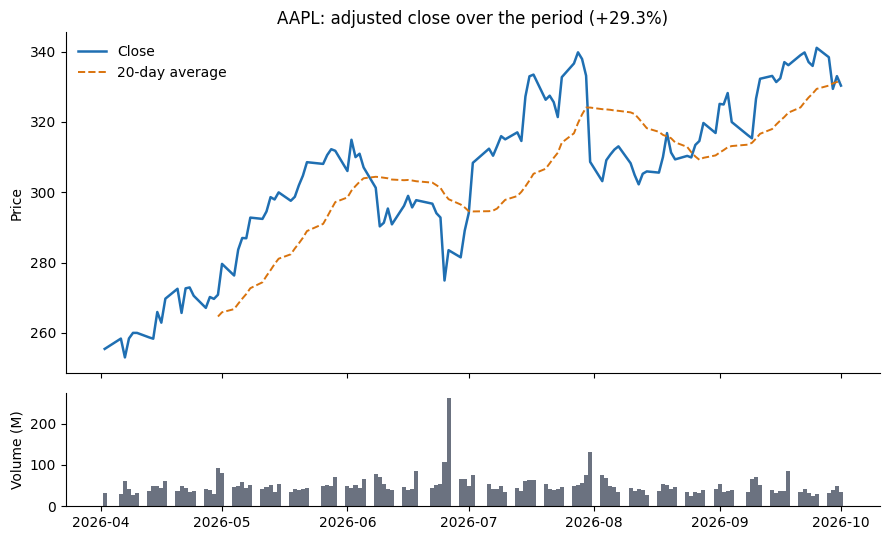

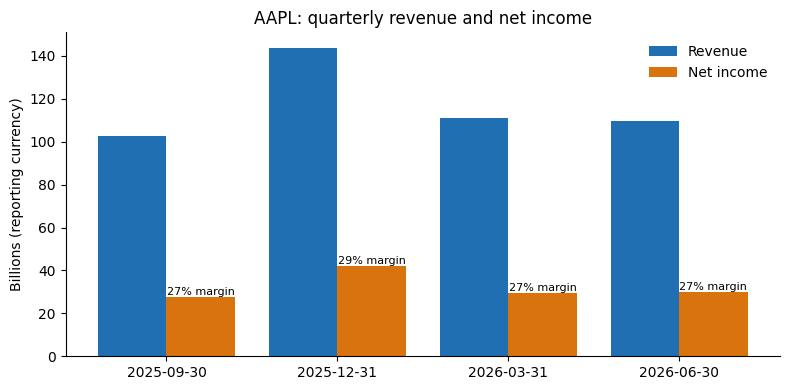

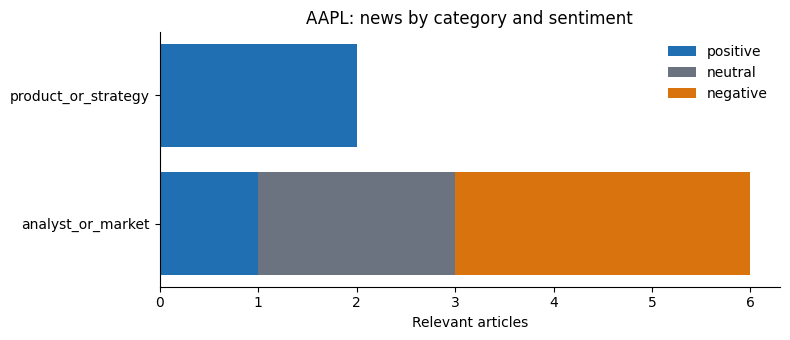

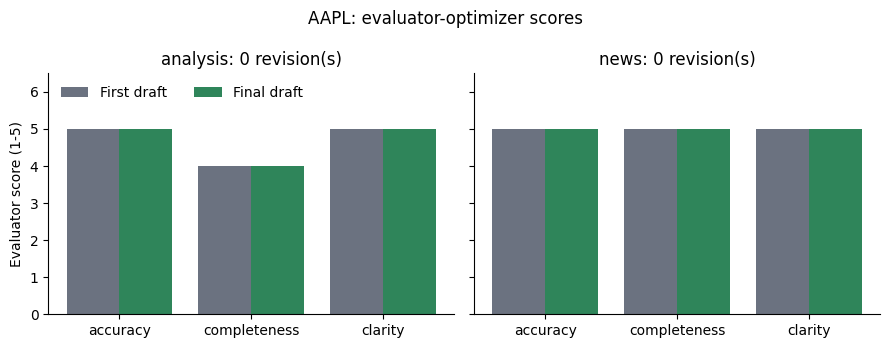

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the last six ...,success
1,Researcher,Coordinator,How has the stock performed over the last six ...,success
2,Coordinator,NewsResearcher,How has the stock performed over the last six ...,success
3,NewsResearcher,Coordinator,How has the stock performed over the last six ...,success
4,Coordinator,Evaluator,How has the stock performed over the last six ...,success
5,Coordinator,Evaluator,How has the stock performed over the last six ...,success


In [21]:
# Run 1: a combined question, so the coordinator should route to both
# specialists and the evaluator-optimizer loop reviews both drafts.
RESET_MEMORY = True  # start the demonstration from an empty memory file
system = InvestmentResearchTeam(client)
if RESET_MEMORY:
    system.memory.clear()

run_1 = system.analyze_stock(
    "AAPL",
    "How has the stock performed over the last six months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="6mo",
)
show_run(run_1)

## 10.3 Run 2: MSFT, using the lessons from run 1

The recalled lessons printed below were learned during run 1 and are injected
into the authors' prompts.

Pausing 60 seconds for rate limits...
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'MSFT', 'period': '3mo'}) → success
Researcher: get_company_financials({'ticker': 'MSFT'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the past three 

# MSFT investment research report

**Question:** How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-01

## Executive summary
Over the three‑month period from 2026‑07‑02 to 2026‑10‑01 the stock advanced from a close of 389.76 to 512.8, an adjusted price change of 31.57% (with a high close of 516.17 and a low close of 380.86). Revenue rose 8.59% QoQ to $90.007 billion in the quarter ended 2026‑06‑30 and net income increased 12.55% QoQ to $35.766 billion, following a prior quarter where revenue grew 1.98% QoQ but net income fell –17.37% QoQ, and an earlier quarter with revenue up 4.63% QoQ and net income up 38.6% QoQ. Recent Yahoo Finance headlines cite AI‑related product launches such as Copilot and a new Humanist AI code of conduct, workforce adjustments including a cut of 268 Xbox roles, and mixed analyst sentiment—four positive and four neutral notes—highlighting a 2% stock gain after the AI conduct announcement and a cited 41% upside potential. The caveat is that this news summary is limited to the supplied headlines and does not include full financial statements or forward‑looking advice.

## Market performance and fundamentals
Over the three‑month period from 2026‑07‑02 to 2026‑10‑01 the stock rose from a close of 389.76 to 512.8, an adjusted price change of 31.57%, reaching a high close of 516.17 and a low close of 380.86 with a maximum drawdown of –5.15%. Daily volatility averaged 2.49% (annualized 39.5%) and average daily volume was 28,613,217 shares. In the quarter ended 2026‑06‑30 revenue was $90.007 billion, up 8.59% quarter‑over‑quarter, and net income was $35.766 billion, up 12.55% QoQ. The prior quarter (ended 2026‑03‑31) showed revenue of $82.886 billion (+1.98% QoQ) and net income of $31.778 billion (‑17.37% QoQ). The quarter ended 2025‑12‑31 reported revenue of $81.273 billion (+4.63% QoQ) and net income of $38.458 billion (+38.6% QoQ); the earliest quarter supplied (2025‑09‑30) does not include QoQ change figures.

| Price metric | Value |
| --- | --- |
| Period | 2026-07-02 to 2026-10-01 |
| Adjusted price change | +31.57% |
| Closing range | 380.86 - 516.17 |
| Maximum drawdown | -5.15% |
| Annualised volatility | 39.50% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-06-30 | 90.01B | 35.77B | 39.74% | +8.59% | +12.55% |
| 2026-03-31 | 82.89B | 31.78B | 38.34% | +1.98% | -17.37% |
| 2025-12-31 | 81.27B | 38.46B | 47.32% | +4.63% | +38.60% |
| 2025-09-30 | 77.67B | 27.75B | 35.72% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
Recent Yahoo Finance headlines about MSFT focus on analyst recommendations, AI‑related product developments such as Copilot and a new Humanist AI code of conduct, workforce changes like the Xbox‑role cuts tied to Activision’s Halo takeover, and discussions of the stock’s valuation and potential upside. The sentiment across the eight articles is fairly balanced, with four pieces expressing positive views (Wells Fargo’s upside call, Oppenheimer’s Copilot outlook, Redburn’s higher price target, and the 2% stock gain after the AI conduct announcement) and four offering neutral perspectives (questions about steam‑running, restructuring reassurance, five‑year run context, and Dynamics 365 rally potential). Key figures cited include a 41% upside potential, a $440 price target, a 2% recent stock gain, a 75% five‑year run, and the reduction of 268 Xbox roles. This summary is limited to the recent Yahoo Finance headlines provided and does not include financial statements, price predictions, or investment advice.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-10-01 | MSFT Stock Lands On Wells Fargo’s Q4 ‘Tactical Ideas List’ – Analyst Sees A 41% Upside Potential | analyst_or_market | positive |
| 2026-09-29 | Has MSFT Stock Run Out Of Steam? | analyst_or_market | neutral |
| 2026-09-26 | Microsoft Copilot Is Turning Into An ‘AI Operating System’ — Here’s What It Means For MSFT Stock, According To Oppenheimer’s Brian Schwartz | product_or_strategy | positive |
| 2026-09-23 | Microsoft Is Cutting 268 Xbox Roles as Activision Takes Over Halo. This Is a Simple Restructuring, Not a Broader Panic Signal for MSFT Stock. | other | neutral |
| 2026-09-21 | Microsoft (MSFT) Stock Looks Reasonable Despite Its 75% Five Year Run | analyst_or_market | neutral |
| 2026-09-21 | MSFT Stock: Redburn Raises Target To $440 As AI Safety, Spending Debate Continues | analyst_or_market | positive |
| 2026-09-14 | MSFT Stock Gains 2% — Microsoft Unveils ‘Humanist AI’ Code Of Conduct To Curb Autonomous AI Risks | product_or_strategy | positive |
| 2026-09-10 | Can MSFT Stock Rally on the Back of Dynamics 365 Business Applications? | analyst_or_market | neutral |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 5 | 5 | 5.0 | approve |
| news | 0 | 4 | 4 | 4 | 4.0 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

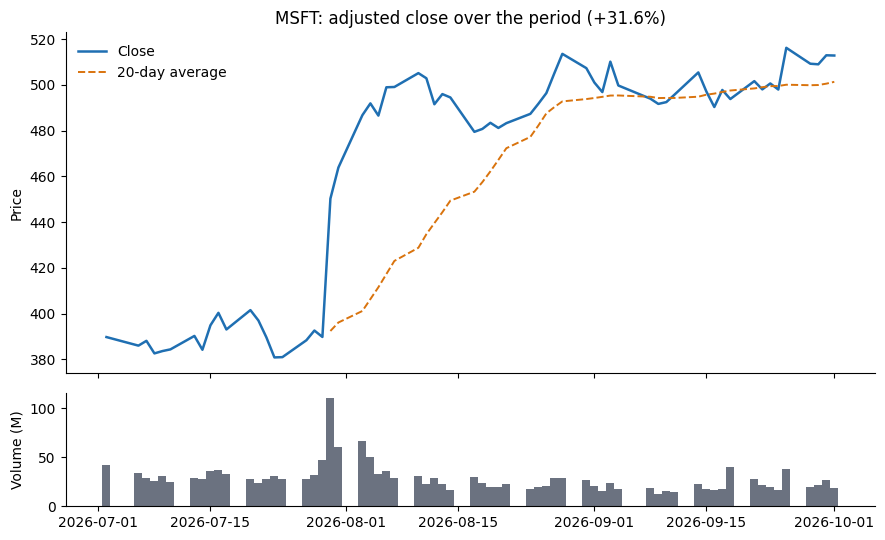

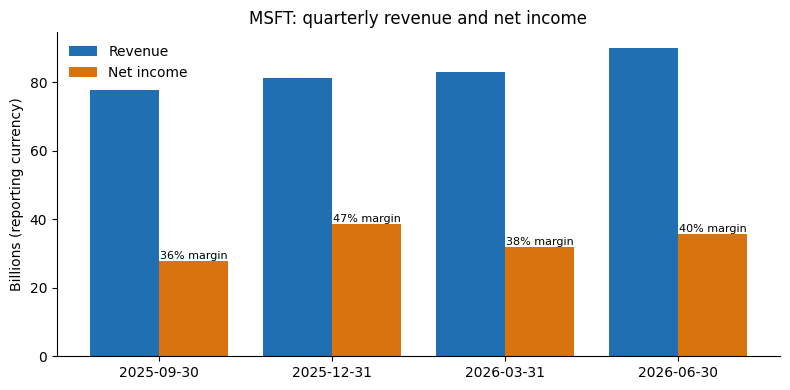

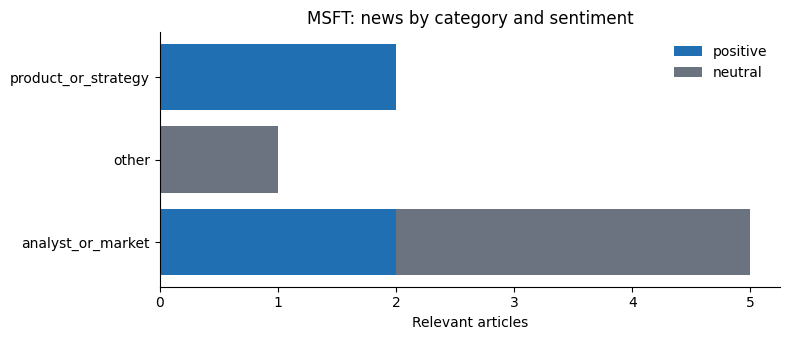

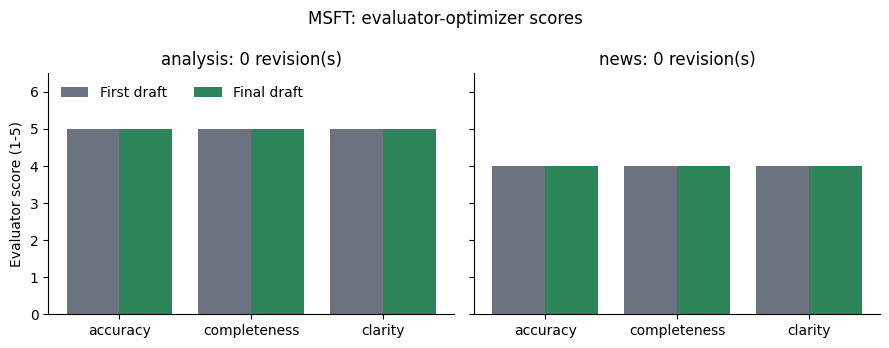

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the past thre...,success
1,Researcher,Coordinator,How has the stock performed over the past thre...,success
2,Coordinator,NewsResearcher,How has the stock performed over the past thre...,success
3,NewsResearcher,Coordinator,How has the stock performed over the past thre...,success
4,Coordinator,Evaluator,How has the stock performed over the past thre...,success
5,Coordinator,Evaluator,How has the stock performed over the past thre...,success


In [22]:
# Pause so the free tier's per-minute rate limit can clear after run 1.
print("Pausing 60 seconds for rate limits...")
time.sleep(60)

# Run 2: a different company. The lessons learned in run 1 are recalled
# and injected into the authors' prompts before they write.
run_2 = system.analyze_stock(
    "MSFT",
    "How has the stock performed over the past three months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="3mo",
)
print("Lessons recalled for run 2:")
for kind, lessons in run_2["lessons_used"].items():
    print(f"  {kind}: {lessons or 'none yet'}")
show_run(run_2)

## 10.4 Inside the evaluator-optimizer loop

The evaluator's feedback, and the first versus revised drafts where a revision happened, for runs 1 and 2. This cell makes no API calls; it only reads the runs already in memory.

In [23]:
import textwrap


def show_evaluation(packet):
    """Print each evaluator round, its feedback, and what was revised."""
    for kind, result in packet.get("evaluation", {}).items():
        print(
            f"\n=== {packet['ticker']} {kind}: {result['revisions']} "
            f"revision(s), final verdict: {result['final_verdict']}"
        )
        for review in result["rounds"]:
            if "scores" not in review:
                print(f"  round {review['round']}: {review['verdict']}")
                continue
            print(
                f"  round {review['round']}: {review['scores']} -> "
                f"{review['verdict']}"
            )
            print(
                textwrap.fill(
                    "feedback: " + review["feedback"],
                    100,
                    initial_indent="    ",
                    subsequent_indent="    ",
                )
            )
        data = packet["analysis"] if kind == "analysis" else packet["news"]
        history = data.get("revision_history", [])
        if history:
            final = (
                data["narrative"] if kind == "analysis" else data["summary"]
            )
            for title, text in (
                ("FIRST DRAFT", history[0]["draft"]),
                ("REVISED DRAFT", final),
            ):
                print(f"\n  {title}:")
                print(
                    textwrap.fill(
                        text, 100, initial_indent="  ", subsequent_indent="  "
                    )
                )


# Uses the runs already in memory: no API calls are made here.
for packet in (run_1, run_2):
    show_evaluation(packet)


=== AAPL analysis: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 4, 'clarity': 5} -> approve
    feedback: Add the September 30 2025 quarter figures (revenue $102.466 billion, net income
    $27.466 billion) or note that quarter‑over‑quarter changes are not available for that period to
    fully cover all reported quarters.

=== AAPL news: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 5, 'clarity': 5} -> approve
    feedback: No changes needed.

=== MSFT analysis: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 5, 'clarity': 5} -> approve
    feedback: No changes needed.

=== MSFT news: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 4, 'completeness': 4, 'clarity': 4} -> approve
    feedback: Remove or qualify the unsupported 'Yahoo Finance' source claim; if the evidence only
    provides headlines, say 'the provided headlines.' Also fix the last sentence because it ci

## 10.5 Run 3: using lessons learned earlier

Runs 1 and 2 left lessons in memory. Run 3 is the first run that starts with stored lessons, so Section 10.6 can compare its first-draft scores with the earlier runs.

Pausing 60 seconds for rate limits...
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'NVDA', 'period': '3mo'}) → success
Researcher: get_company_financials({'ticker': 'NVDA'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the past three 

# NVDA investment research report

**Question:** How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-01

## Executive summary
Over the three‑month period from July 2 2026 to October 1 2026 NVDA’s share price rose 18.63% (adjusted), reaching a high close of 230.86 and a low close of 189.8. In the quarter ended July 31 2026 revenue grew 17.9% QoQ and net income rose 2.34% QoQ, whereas the prior quarter (ended April 30 2026) showed revenue up 19.8% QoQ and net income up 35.76% QoQ, and the quarter ended January 31 2026 had revenue up 19.51% QoQ and net income up 34.63% QoQ. Recent Yahoo Finance headlines note a third straight monthly gain, the stock climbing after Nvidia approved its largest‑ever buyback increase, and a headline claim of 106% revenue growth in a recent quarter (presented as an unverified statement), together with neutral news about possible chip sales to China and an IPO filing by Nvidia‑backed Nscale. The analysis relies only on recent Yahoo Finance headlines, and the 106% revenue figure is not a verified financial‑statement number, so no definitive link between news and performance can be asserted.

## Market performance and fundamentals
Over the three‑month period from July 2 2026 to October 1 2026, NVDA’s share price rose from a close of 194.61 to 230.86, an adjusted price change of 18.63 %. During that span the stock reached a high close of 230.86 and a low close of 189.8, with a maximum drawdown of –10.58 %, daily volatility of 2.42 % and annualized volatility of 38.41 %. In the quarter ending July 31 2026 revenue was 96,221,000,000, up 17.9 % quarter‑over‑quarter, while net income was 59,688,000,000, up 2.34 % QoQ. The prior quarter (ended April 30 2026) showed revenue of 81,615,000,000 (+19.8 % QoQ) and net income of 58,321,000,000 (+35.76 % QoQ). Earlier, the quarter ended January 31 2026 reported revenue of 68,127,000,000 (+19.51 % QoQ) and net income of 42,960,000,000 (+34.63 % QoQ).

| Price metric | Value |
| --- | --- |
| Period | 2026-07-02 to 2026-10-01 |
| Adjusted price change | +18.63% |
| Closing range | 189.8 - 230.86 |
| Maximum drawdown | -10.58% |
| Annualised volatility | 38.41% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-07-31 | 96.22B | 59.69B | 62.03% | +17.90% | +2.34% |
| 2026-04-30 | 81.61B | 58.32B | 71.46% | +19.80% | +35.76% |
| 2026-01-31 | 68.13B | 42.96B | 63.06% | +19.51% | +34.63% |
| 2025-10-31 | 57.01B | 31.91B | 55.98% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
Recent Yahoo Finance headlines highlight positive price actions, such as references to a third straight monthly gain, the stock trading up on a given day, and climbing after Nvidia approved its largest‑ever buyback increase. The same set of headlines cites a headline claim of 106% revenue growth in a recent quarter, while noting that this figure is presented as a headline statement rather than a verified financial‑statement number. Other recent items include reports that China may allow ByteDance and Alibaba to purchase some Nvidia AI chips and the filing for an IPO by Nvidia‑backed cloud platform Nscale, both noted as neutral‑sentiment news that could influence investor focus. Overall sentiment across the sampled headlines is largely positive, with a few neutral items and one cautionary note about a possible discount despite the rally. Coverage is limited to recent Yahoo Finance headlines, and no net‑income figures or price predictions are provided.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-09-30 | NVDA Stock Eyes Third Straight Monthly Gain: Nvidia Adds Data Center Digital Twin Deal | product_or_strategy | positive |
| 2026-09-28 | Why Nvidia (NVDA) Stock Is Trading Up Today | analyst_or_market | positive |
| 2026-09-28 | Nvidia Just Delivered 106% Revenue Growth. What Could NVDA Stock Do Next? | earnings | positive |
| 2026-09-28 | NVDA Stock Climbs After Nvidia Approves ‘Largest Buyback Increase’ In Company History | product_or_strategy | positive |
| 2026-09-28 | NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips | regulatory_or_legal | neutral |
| 2026-09-27 | China May Reopen Nvidia's AI Market. How Will NVDA Stock React Monday? | regulatory_or_legal | neutral |
| 2026-09-27 | Nvidia (NVDA) Stock Could Trade At A Discount Despite Its 10x Run | analyst_or_market | negative |
| 2026-09-18 | Nvidia-Backed Cloud Platform Nscale Files For IPO — NVDA Stock In Focus | product_or_strategy | neutral |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 5 | 5 | 5.0 | approve |
| news | 0 | 4 | 3 | 5 | 4.0 | revise |
| news | 1 | 4 | 4 | 5 | 4.33 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

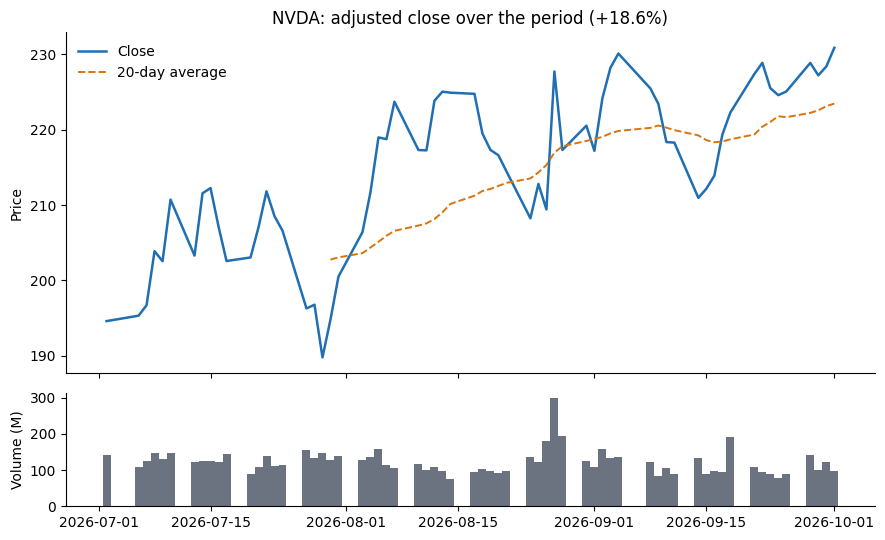

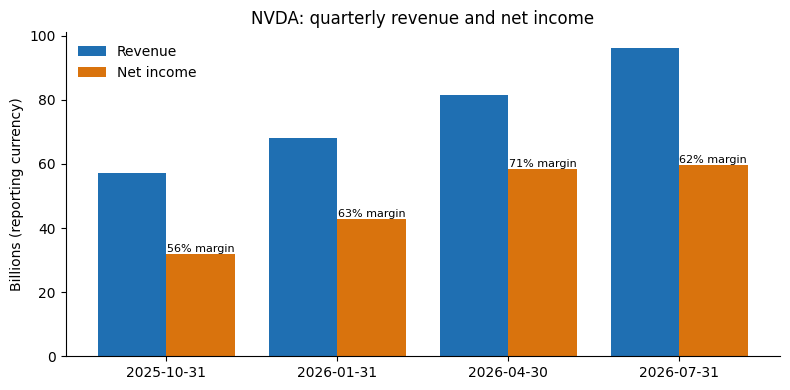

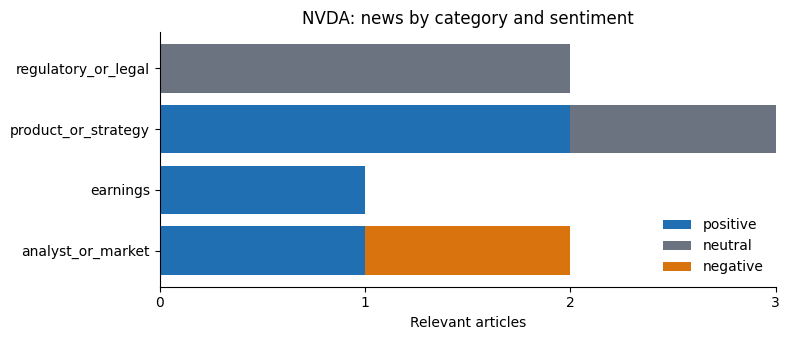

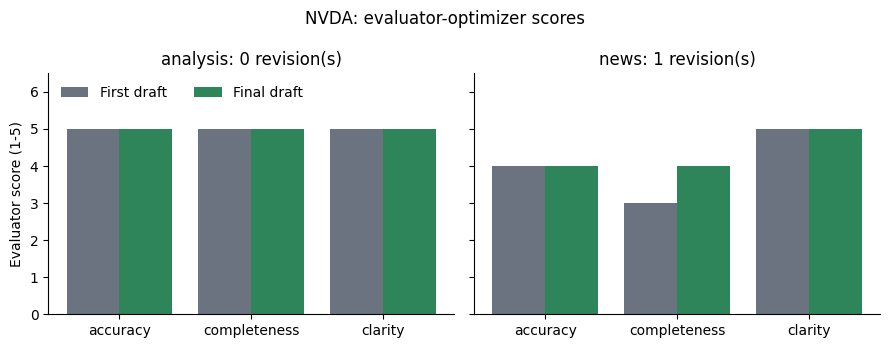

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the past thre...,success
1,Researcher,Coordinator,How has the stock performed over the past thre...,success
2,Coordinator,NewsResearcher,How has the stock performed over the past thre...,success
3,NewsResearcher,Coordinator,How has the stock performed over the past thre...,success
4,Coordinator,Evaluator,How has the stock performed over the past thre...,success
5,Coordinator,Evaluator,How has the stock performed over the past thre...,success
6,Coordinator,NewsResearcher,revise news,success
7,Coordinator,Evaluator,How has the stock performed over the past thre...,success



=== NVDA analysis: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 5, 'clarity': 5} -> approve
    feedback: No changes needed.

=== NVDA news: 1 revision(s), final verdict: approve
  round 0: {'accuracy': 4, 'completeness': 3, 'clarity': 5} -> revise
    feedback: Tighten the news-only focus by removing the three-month price-trend inference, since
    the evidence supports only recent headline references. Add the omitted relevant recent items:
    reports that China may allow ByteDance and Alibaba to buy some Nvidia AI chips, and the Nvidia-
    backed Nscale IPO filing. Also make clear that the 106% revenue growth is a headline claim, not
    a verified financial statement figure.
  round 1: {'accuracy': 4, 'completeness': 4, 'clarity': 5} -> approve
    feedback: Add the data-center digital-twin deal from A1 as a separate recent news factor.
    Explicitly tie the listed items—the 106% revenue-growth headline, buyback increase, China chip-
    acces

In [24]:
# Run 3: a third company. The lesson stored after run 2 is now recalled
# and given to the authors before they write.
print("Pausing 60 seconds for rate limits...")
time.sleep(60)

run_3 = system.analyze_stock(
    "NVDA",
    "How has the stock performed over the past three months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="3mo",
)
print("Lessons recalled for run 3:")
for kind, lessons in run_3["lessons_used"].items():
    print(f"  {kind}: {lessons or 'none yet'}")
show_run(run_3)
show_evaluation(run_3)

## 10.6 What the system remembers

In [25]:
# What the system remembers: scores per run and the stored lessons.
history = system.memory.history()
display(
    history[[
        "ticker",
        "kind",
        "first_mean",
        "final_mean",
        "revisions",
        "lessons_used",
    ]]
)
print("\nStored lessons:")
for item in system.memory.data["lessons"]:
    print(f"  [{item['kind']}] {item['lesson']}")
display(system.show_team_status())
print("Handoff file written to:", save_handoff(run_3, "research_run.json"))

,ticker,kind,first_mean,final_mean,revisions,lessons_used
0,AAPL,analysis,4.67,4.67,0,0
1,AAPL,news,5.00,5.00,0,0
2,MSFT,analysis,5.00,5.00,0,1
3,MSFT,news,4.00,4.00,0,0
4,NVDA,analysis,5.00,5.00,0,1
5,NVDA,news,4.00,4.33,1,1



Stored lessons:
  [analysis] When reporting quarterly data, either provide the specific figures for the period or explicitly state that such data are not available.
  [news] Always qualify sources as headlines when evidence is limited, avoid stating price targets or predictions, and connect news to the question with a neutral, non‑advisory context.
  [news] Limit discussion to verified recent headlines, omit speculative trend inferences, and label any growth figures as claims unless sourced from official statements.


,agent,completed_tasks_this_session
0,Coordinator,6
1,Researcher,3
2,NewsResearcher,3
3,Evaluator,7


Handoff file written to: /content/research_run.json


---
# 11. Conclusions, Limitations and Future Improvements

## Conclusions

The system implements all four agent functions (planning, dynamic tool use,
self-reflection, learning across runs) and all three workflow patterns
(prompt chaining, routing, evaluator-optimizer) on free models and free data.
The main lesson from building it is to divide the work: the LLMs choose and
explain, while ordinary code computes numbers, validates outputs, bounds loops
and decides verdicts. That separation is what made unreliable free models
usable: invalid answers are caught and retried, failures degrade visibly
instead of being hidden, and no draft is accepted with a figure that is not in
the evidence. Results of the final run are shown in Section 10; the score
history there is the evidence for whether review and memory helped.

## Limitations

* **Model reliability:** free models are rate limited and sometimes return
  errors or malformed JSON; runs can fail and need a retry, and results vary
  between runs.
* **Data:** Yahoo Finance data comes through an unofficial library and is not
  independently verified; only four quarters are available, so there is no
  year-over-year comparison; no earnings dates, guidance, analyst estimates,
  filings or macroeconomic data are used.
* **News:** only the headlines and summaries Yahoo returns; category and
  sentiment are model judgements, and a few articles are a small sample.
* **Evaluation:** an LLM reviews LLM output. The grounding check catches wrong
  percentages but not wrong reasoning, and the approval thresholds are
  heuristic. The effect of memory is shown on a few runs, not a controlled
  experiment.
* **Memory:** a small JSON file of one-sentence rules, with no ranking or
  forgetting beyond a size cap.
* **Scope:** this is research support, not investment advice, and it does not
  predict prices.

## Future improvements

* Add SEC EDGAR filings and FRED macro data as new tools and a third
  specialist, using the same routing pattern.
* Use a stronger paid model for the evaluator, and compare it with human
  ratings on a labelled set of drafts.
* Store lessons with embeddings and retrieve by similarity instead of recency.
* Run the two specialists in parallel and cache tool results to save time and
  requests.
* Add a controlled experiment: many tickers with and without memory, to
  measure the change in first-draft scores.
* Add a human-in-the-loop approval step before the final report.

---
# 12. References

* Yao, S., et al. (2023). *ReAct: Synergizing Reasoning and Acting in
  Language Models.* ICLR. arXiv:2210.03629.
* Madaan, A., et al. (2023). *Self-Refine: Iterative Refinement with
  Self-Feedback.* NeurIPS. arXiv:2303.17651.
* Shinn, N., et al. (2023). *Reflexion: Language Agents with Verbal
  Reinforcement Learning.* NeurIPS. arXiv:2303.11366.
* Anthropic (2024). *Building effective agents* (prompt chaining, routing and
  evaluator-optimizer workflows). anthropic.com/research/building-effective-agents
* yfinance documentation: https://github.com/ranaroussi/yfinance
* OpenRouter API documentation: https://openrouter.ai/docs
* JSON Schema (draft 2020-12) and the `jsonschema` Python package.
* van Rossum, G., Warsaw, B., Coghlan, A. *PEP 8: Style Guide for Python
  Code.* https://peps.python.org/pep-0008/
* University of San Diego, Applied Artificial Intelligence program: course
  Lab 7 and Presentation 7.1, *Agentic AI*.